In [1]:
import os
# Force CPU backend on Apple Silicon to avoid Metal issues
os.environ['JAX_PLATFORMS'] = 'cpu'

# Disable LaTeX rendering in matplotlib
import matplotlib.pyplot as plt
plt.rcParams["text.usetex"] = False
plt.rcParams["font.family"] = "sans-serif"

from pathlib import Path
from jax import random
from jax import numpy as jnp
from sbijax import plot_loss_profile
import pickle
from sbijax import NLE
from sbijax.nn import make_maf

from aind_behavior_vrforaging_analysis.sbi_ddm_analysis.simulator import PatchForagingDDM_JAX, create_prior
from aind_behavior_vrforaging_analysis.sbi_ddm_analysis.snle.snle_inference_jax import train_snle, infer_parameters_snle
from aind_behavior_vrforaging_analysis.sbi_ddm_analysis.snle.snle_utils_jax import plot_real_synth_hist, extract_samples
from aind_behavior_vrforaging_analysis.sbi_ddm_analysis.enhanced_stats_37 import FEATURE_NAMES

from aind_behavior_vrforaging_analysis.sbi_ddm_analysis.sbi_pipeline import (
    validate_parameter_recovery,
    infer_parameters_per_window,
    analyze_temporal_dynamics,
    compare_odors_temporal
)

In [2]:
def get_model_directory(config, make_dir = False):
    """
    Create descriptive directory name from config parameters and handle duplicates.
    
    Example output: snle_2M_lr0.0001_ts200_h128_l8_b2048_23feat/
    If exists, creates: snle_2M_lr0.0001_ts200_h128_l8_b2048_23feat_1/
    
    Returns:
        model_dir: Path to model directory
        checkpoint_dir: Path to checkpoint subdirectory
    """
    n_sims = config['n_simulations']
    hidden_dim = config['hidden_dim']
    num_layers = config['num_layers']
    batch_size = config['batch_size']
    learning_rate = config['learning_rate']
    transition_steps = config['transition_steps']
    n_feat = config['n_feat']
    base_output_dir = config['base_output_dir']
    
    # Format number of simulations nicely
    if n_sims >= 1_000_000:
        n_sims_str = f"{n_sims // 1_000_000}M"
    elif n_sims >= 1_000:
        n_sims_str = f"{n_sims // 1_000}K"
    else:
        n_sims_str = str(n_sims)
    
    # Get number of features from simulator
    rng_key = random.PRNGKey(config['seed'])
    rng_key, test_key = random.split(rng_key)
    test_theta = prior_fn().sample(seed=test_key)

    simulator = PatchForagingDDM_JAX(
        initial_prob=0.8,
        depletion_rate=-0.1,
        threshold=1.0,
        start_point=0.0,
        interval_min=config['interval_min'],
        interval_scale=config['interval_scale'],
        interval_normalization=config['interval_normalization'],
        odor_site_length=config['odor_site_length'],
        # learning_rate=config['learning_rate'],
        # transition_steps=config['transition_steps'],
        # decay_rate=config['decay_rate'],
        max_sites_per_window=config['window_size'],
        n_feat=n_feat
    )
    
    # Create base directory name
    base_name = f"snle_{n_sims_str}_lr{learning_rate}_ts{transition_steps}_h{hidden_dim}_l{num_layers}_b{batch_size}_{n_feat}feat"
    
    # Handle duplicates by adding _0, _1, _2, etc.
    model_dir = base_output_dir / base_name
    if make_dir == True:
        counter = 0
        while model_dir.exists() and any(model_dir.iterdir()):  # Check if folder exists AND has files
            model_dir = base_output_dir / f"{base_name}_{counter}"
            counter += 1
    
    # Create model directory and checkpoint subdirectory
    model_dir.mkdir(parents=True, exist_ok=True)
    checkpoint_dir = model_dir / "checkpoints"
    checkpoint_dir.mkdir(exist_ok=True)
    
    print(f"Model directory: {model_dir}")
    print(f"Checkpoint directory: {checkpoint_dir}")
    
    return model_dir, checkpoint_dir

In [ ]:
# ============================================================================
# Configuration
# ============================================================================

CONFIG = {
    'base_path': Path("/Users/laura.driscoll/Documents/data/VR foraging/vr_foraging_data"),
    'base_output_dir': Path("/Users/laura.driscoll/Documents/code/sbi_results"),
    'filename': [],
    'window_size': 100,
    'n_feat': 37,
    'odor_types': ['Methyl_Butyrate', 'Alpha_pinene'],
    'odor_display_names': {'Methyl_Butyrate': 'Methyl Butyrate', 'Alpha_pinene': 'Alpha-pinene'},
    
    'interval_min': 20.0,
    'interval_scale': 19.0,
    'odor_site_length': 50.0,
    'interval_normalization': 88.73,

    'prior_low': [-.3, -1.3, -.3, 0.0],
    'prior_high': [1.3,  1.3,  2,  0.3],
    
    'n_simulations': 2_000_000,
    'n_iter': 1000,
    'batch_size': 128,
    'n_early_stopping_patience': 10,
    'hidden_dim': 128,
    'num_layers': 8,

    'learning_rate': 9e-4,
    'transition_steps': 2000,
    'decay_rate': .99,
    
    'checkpoint_every': 20,  # Save checkpoint every 20 iterations
    'force_retrain' : False, # saves as model_path_1 if exists when false, forces overwrite when true
    
    'num_samples': 500,
    'num_warmup': 200,
    'num_chains': 2,
    
    'seed': 0
}

# model_dir, _ = get_model_directory(CONFIG, make_dir = True)
# CONFIG['filename'] = model_dir
# # Create base output directory
# CONFIG['base_output_dir'].mkdir(exist_ok=True, parents=True)

# Model-specific directories will be created when training
param_names = ['drift_rate', 'reward_bump', 'failure_bump', 'noise_std']

print("Configuration loaded")
print(f"Model directory: {CONFIG['filename']}")

Configuration loaded
Model directory: []


In [4]:
# simulator = PatchForagingDDM_JAX(
#     initial_prob=0.8,
#     decay_rate=-0.1,
#     threshold=1.0,
#     start_point=0.0,
#     interval_min=CONFIG['interval_min'],
#     interval_scale=CONFIG['interval_scale'],
#     interval_normalization=CONFIG['interval_normalization'],
#     odor_site_length=CONFIG['odor_site_length'],
#     max_sites_per_window=CONFIG['window_size']
# )

# prior_fn = create_prior(
#     prior_low=jnp.array(CONFIG['prior_low']),
#     prior_high=jnp.array(CONFIG['prior_high'])
# )

# print("Simulator initialized")


# # Quick test configs (10% of full data)
# test_configs = [
#     {'hidden_dim': 64, 'num_layers': 5, 'name': 'current'},
#     {'hidden_dim': 48, 'num_layers': 4, 'name': 'medium'},
#     {'hidden_dim': 32, 'num_layers': 3, 'name': 'small'},
# ]

# for config in test_configs:
#     print(f"\nTesting {config['name']}...")
    
#     snle, params, losses, _, y_mean, y_std = train_snle(
#         simulator,
#         prior_fn,
#         mode='multi',
#         n_simulations=200_000,  # 10% for quick test
#         n_iter=500,             # Half iterations
#         hidden_dim=config['hidden_dim'],
#         num_layers=config['num_layers'],
#         batch_size=256,
#         n_early_stopping_patience=35,
#         rng_key=random.PRNGKey(42)
#     )
    
#     # Quick SBC test (10 runs)
#     sbc_ranks = run_quick_sbc(snle, params, y_mean, y_std, n_tests=10)
    
#     print(f"  Final loss: {losses[-1]:.4f}")
#     print(f"  Training time: {time_taken:.1f}s")

In [5]:
# ============================================================================
# STEP 1: Initialize and Train
# ============================================================================

simulator = PatchForagingDDM_JAX(
    initial_prob=0.8,
    depletion_rate=-0.1,
    threshold=1.0,
    start_point=0.0,
    interval_min=CONFIG['interval_min'],
    interval_scale=CONFIG['interval_scale'],
    interval_normalization=CONFIG['interval_normalization'],
    odor_site_length=CONFIG['odor_site_length'],
    max_sites_per_window=CONFIG['window_size'],
    n_feat=CONFIG['n_feat']
)

prior_fn = create_prior(
    prior_low=jnp.array(CONFIG['prior_low']),
    prior_high=jnp.array(CONFIG['prior_high'])
)

print("Simulator initialized")

# Create model directory and get checkpoint directory
model_dir, checkpoint_dir = get_model_directory(CONFIG)
model_path = model_dir / "model.pkl"

print(f"Model directory: {model_dir}")
print(f"Model file: {model_path}")

if model_path.exists() and not CONFIG['force_retrain']:
    print(f"Loading existing model from {model_path}")
    with open(model_path, 'rb') as f:
        model_data = pickle.load(f)
    snle = model_data['snle']
    snle_params = model_data['snle_params']
    y_mean = model_data['y_mean']
    y_std = model_data['y_std']
    print("✓ Model loaded successfully")
else:
    print(f"Training new SNLE model...")
    print(f"Config: {CONFIG}")

    rng_key = random.PRNGKey(CONFIG['seed'])

    snle, snle_params, losses, rng_key, y_mean, y_std = train_snle(
        simulator,
        prior_fn,
        mode='multi',
        n_simulations=CONFIG['n_simulations'],
        hidden_dim=CONFIG['hidden_dim'],
        num_layers=CONFIG['num_layers'],
        n_iter=CONFIG['n_iter'],
        batch_size=CONFIG['batch_size'],
        n_early_stopping_patience=CONFIG['n_early_stopping_patience'],
        learning_rate = CONFIG['learning_rate'],
        transition_steps = CONFIG['transition_steps'],
        decay_rate = CONFIG['decay_rate'],
        percentage_data_as_validation_set=0.1,
        rng_key=rng_key,
        save_dir=str(checkpoint_dir),
        checkpoint_every=CONFIG['checkpoint_every']
    
    )
        
    # Save final model with descriptive filename
    print(f"\nSaving final model to {model_path}")
    model_data = {
        'snle_params': snle_params,
        'losses': losses,
        'y_mean': y_mean,
        'y_std': y_std,
        'config': CONFIG,
        'model_dir': str(model_dir),
        'checkpoint_dir': str(checkpoint_dir)
    }

with open(model_path, 'wb') as f:
    pickle.dump(model_data, f)

    print(f"✓ Model saved successfully to {model_path}")
    print(f"✓ Checkpoints saved in {checkpoint_dir}")

print("\n" + "="*80)
print("Training complete!")
print(f"Model directory: {model_dir}")
print("="*80)


Simulator initialized
Model directory: /Users/laura.driscoll/Documents/code/sbi_results/snle_2M_lr0.001_ts20000_h128_l8_b128_37feat
Checkpoint directory: /Users/laura.driscoll/Documents/code/sbi_results/snle_2M_lr0.001_ts20000_h128_l8_b128_37feat/checkpoints
Model directory: /Users/laura.driscoll/Documents/code/sbi_results/snle_2M_lr0.001_ts20000_h128_l8_b128_37feat
Model file: /Users/laura.driscoll/Documents/code/sbi_results/snle_2M_lr0.001_ts20000_h128_l8_b128_37feat/model.pkl
Training new SNLE model...
Config: {'base_path': PosixPath('/Users/laura.driscoll/Documents/data/VR foraging/vr_foraging_data'), 'base_output_dir': PosixPath('/Users/laura.driscoll/Documents/code/sbi_results'), 'filename': [], 'window_size': 100, 'n_feat': 37, 'odor_types': ['Methyl_Butyrate', 'Alpha_pinene'], 'odor_display_names': {'Methyl_Butyrate': 'Methyl Butyrate', 'Alpha_pinene': 'Alpha-pinene'}, 'interval_min': 20.0, 'interval_scale': 19.0, 'odor_site_length': 50.0, 'interval_normalization': 88.73, 'prio

python(27321) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
  3%|▎         | 30/1000 [4:33:15<147:15:22, 546.52s/it] 


Saving final model to /Users/laura.driscoll/Documents/code/sbi_results/snle_2M_lr0.001_ts20000_h128_l8_b128_37feat/model.pkl
✓ Model saved successfully to /Users/laura.driscoll/Documents/code/sbi_results/snle_2M_lr0.001_ts20000_h128_l8_b128_37feat/model.pkl
✓ Checkpoints saved in /Users/laura.driscoll/Documents/code/sbi_results/snle_2M_lr0.001_ts20000_h128_l8_b128_37feat/checkpoints

Training complete!
Model directory: /Users/laura.driscoll/Documents/code/sbi_results/snle_2M_lr0.001_ts20000_h128_l8_b128_37feat


In [6]:
# Save with descriptive filename
print(f"\nSaving model to {model_path}")
model_data = {
    'snle_params': snle_params,
    'losses': losses,
    'y_mean': y_mean,
    'y_std': y_std,
    'config': CONFIG,  # Save config too!
}

with open(model_path, 'wb') as f:
    pickle.dump(model_data, f)

print(f"✓ Model saved successfully")


Saving model to /Users/laura.driscoll/Documents/code/sbi_results/snle_2M_lr0.0008_ts2000_h128_l8_b128_37feat/model.pkl
✓ Model saved successfully


In [7]:
with open(model_path, 'rb') as f:
    model_data = pickle.load(f)

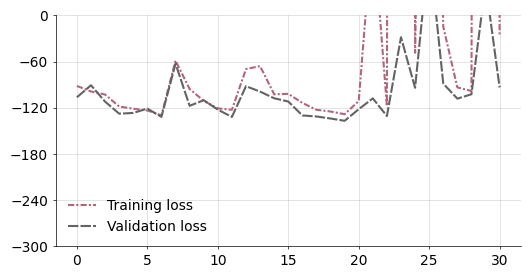

In [7]:
# Disable LaTeX rendering in matplotlib
plt.rcParams["text.usetex"] = False
plt.rcParams["font.family"] = "sans-serif"

_, axes = plt.subplots(figsize=(6, 3))
plot_loss_profile(model_data['losses'], axes)
axes.set_ylim([ -300,0])
plt.show()

In [9]:
CONFIG = model_data['config']
# model_filename,_ = get_model_directory(CONFIG)
# model_path = Path(CONFIG['base_output_dir']) / model_filename

with open(model_path, 'rb') as f:
    model_data = pickle.load(f)

# Reconstruct SNLE
simulator = PatchForagingDDM_JAX(max_sites_per_window=100, n_feat = CONFIG['n_feat'])
prior_fn = create_prior(
    prior_low=jnp.array(CONFIG['prior_low']),
    prior_high=jnp.array(CONFIG['prior_high'])
)

rng_key = random.PRNGKey(CONFIG['seed'])
rng_key, test_key = random.split(rng_key)
test_theta = prior_fn().sample(seed=test_key)
test_x = simulator.simulator_fn(seed=test_key, theta=test_theta)
n_features = test_x.shape[-1]

flow = make_maf(
    n_dimension=n_features, # obs data dimension
    n_layers=CONFIG['num_layers'],
    hidden_sizes=(CONFIG['hidden_dim'], CONFIG['hidden_dim']),
)

snle = NLE((prior_fn, simulator.simulator_fn), flow)

print("✓ Model loaded!")

✓ Model loaded!


In [10]:
# # Load saved parameters
# with open(f'/Users/laura.driscoll/Documents/code/sbi_results/snle_params_{CONFIG["n_simulations"]:,}.pkl', 'rb') as f:
#     saved_data = pickle.load(f)

# # Reconstruct the model
# simulator = PatchForagingDDM_JAX(
#     max_sites_per_window=100,
#     interval_normalization=saved_data['config']['interval_normalization']
# )
# prior_fn = create_prior(
#     prior_low=jnp.array(saved_data['config']['prior_low']),
#     prior_high=jnp.array(saved_data['config']['prior_high'])
# )

# # Rebuild the flow architecture (must match training)
# flow = make_maf(
#     n_dimension=23,
#     n_layers=saved_data['config']['num_layers'],
#     hidden_sizes=(saved_data['config']['hidden_dim'], saved_data['config']['hidden_dim'])
# )

# # Create SNLE model
# fns = prior_fn, simulator.simulator_fn
# snle = NLE(fns, flow)

# print("Model reconstructed! Ready for inference.")

In [11]:
# --- Simulate observed data ---
print("\n2. Simulating observed data...")
rng_key, subkey = random.split(rng_key)
true_theta = prior_fn().sample(seed=subkey)['theta']
rng_key, subkey = random.split(rng_key)
_, observed_stats = simulator.simulate_one_window(true_theta, subkey)
print(f"   True theta: {true_theta}")
print(f"   Observed stats: {observed_stats}")


2. Simulating observed data...
   True theta: [ 1.1292076  -0.75609016  0.750663    0.11576869]
   Observed stats: [1.71641374e+00 9.01497722e-01 1.86392948e-01 2.29999989e-01
 4.20832485e-01 1.40000001e-01 3.46987009e-01 1.71641374e+00
 8.61733735e-01 0.00000000e+00 6.94795921e-02 8.48505199e-01
 9.62545395e-01 2.19928667e-01 1.14040196e-01 8.61575902e-01
 8.02664876e-01 8.55907738e-01 9.21624959e-01 1.18960083e-01
 0.00000000e+00 0.00000000e+00 8.20918918e-01 6.08695626e-01
 5.62857132e+01 6.08695626e-01 2.30000000e+01 4.34782600e+00
 2.29999989e-01 0.00000000e+00 8.06276798e-02 1.75955161e-01
 0.00000000e+00 6.97233319e-01 3.02637390e+02 8.14916015e-01
 3.97639871e-02]


In [12]:
# --- Run inference ---
print("\n3. Testing inference...")
rng_key, subkey = random.split(rng_key)
posterior_samples, diagnostics = infer_parameters_snle(
snle,
model_data['snle_params'],
observed_stats, 
model_data['y_mean'], model_data['y_std'],
num_samples=1_000,
num_warmup=500,
num_chains=4,
rng_key=subkey
)


3. Testing inference...

Normalizing observed statistics...

Running MCMC inference...
Posterior dataset variables: ['theta']
Posterior theta shape (chain, draw, n_params): (4, 500, 4)
Posterior samples shape (flattened): (2000, 4)


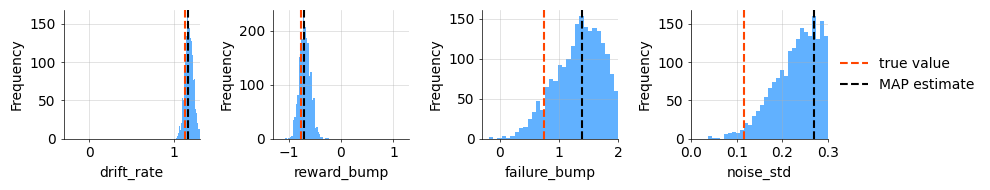

In [13]:
# --- Plot posterior distributions ---
param_names = ["drift_rate", "reward_bump", "failure_bump", "noise_std"]
param_labels = [
    "drift_rate: evidence accumulation rate",
    "reward_bump: evidence drop from receiving reward",
    "failure_bump: evidence boost from not receiving reward",
    "noise_std: std of noise in evidence accumulation"
]

fig, axes = plt.subplots(1, 4, figsize=(10, 2))
axes = axes.flatten()

for i in range(4):

    # Compute histogram
    counts, bins, _ =axes[i].hist(posterior_samples[:, i], bins=30, color='dodgerblue', edgecolor=None, alpha=0.7)

    # Posterior mode (bin center with max count)
    mode_index = jnp.argmax(counts)
    posterior_mode = (bins[mode_index] + bins[mode_index + 1]) / 2

    axes[i].axvline(true_theta[i], color='orangered', linestyle='--', label="true value")
    axes[i].axvline(posterior_mode, color='k', linestyle='--', label='MAP estimate')

    axes[i].set_xlabel(param_names[i])
    axes[i].set_xlim(CONFIG['prior_low'][i], CONFIG['prior_high'][i])
    axes[i].set_ylabel("Frequency")

axes[i].legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()


In [14]:
from scipy.stats import gaussian_kde
import numpy as np

def pairplot(posterior_samples, true_params=None, param_names=None, figsize_per_param=2.5, grid_points=100):
    """
    Lower-triangle corner plot with:
    - 2D filled KDEs (off-diagonal)
    - 1D KDEs (diagonal)
    - Red 'X' for true parameters
    """
    if isinstance(posterior_samples, jnp.ndarray):
        posterior_samples = np.array(posterior_samples)
    
    n_params = posterior_samples.shape[1]
    if param_names is None:
        param_names = [f"param{i}" for i in range(n_params)]
    
    fig, axes = plt.subplots(n_params, n_params, figsize=(figsize_per_param*n_params, figsize_per_param*n_params))
    
    for i in range(n_params):
        for j in range(n_params):
            ax = axes[i, j]
            
            # Only fill lower triangle
            if i < j:
                ax.axis('off')
                continue
            
            # Diagonal: 1D KDE
            if i == j:
                data = posterior_samples[:, i]
                kde = gaussian_kde(data)
                x_grid = np.linspace(data.min(), data.max(), grid_points)
                ax.fill_between(x_grid, kde(x_grid), color="skyblue")
                
                if true_params is not None:
                    ax.axvline(true_params[i], color='red', linestyle='--', lw=1)
            
            # Off-diagonal: 2D KDE
            else:
                x = posterior_samples[:, j]
                y = posterior_samples[:, i]
                xy = np.vstack([x, y])
                kde = gaussian_kde(xy)
                x_grid = np.linspace(x.min(), x.max(), grid_points)
                y_grid = np.linspace(y.min(), y.max(), grid_points)
                X, Y = np.meshgrid(x_grid, y_grid)
                Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)
                ax.contourf(X, Y, Z, levels=20, cmap="Blues")
                
                if true_params is not None:
                    ax.scatter(true_params[j], true_params[i], c='red', s=50, marker='X', label='True')
            
            # Only label left and bottom axes
            if i < n_params - 1:
                ax.set_xticklabels([])
            else:
                ax.set_xlabel(param_names[j])
            if j > 0:
                ax.set_yticklabels([])
            else:
                ax.set_ylabel(param_names[i])
    
    # Add a legend in the top-left subplot
    handles = []
    if true_params is not None:
        handles.append(plt.Line2D([0], [0], marker='X', color='w', markerfacecolor='red', markersize=8, label='True'))
    axes[0, 1].legend(handles=handles, loc='upper left')
    
    plt.tight_layout()
    plt.show()

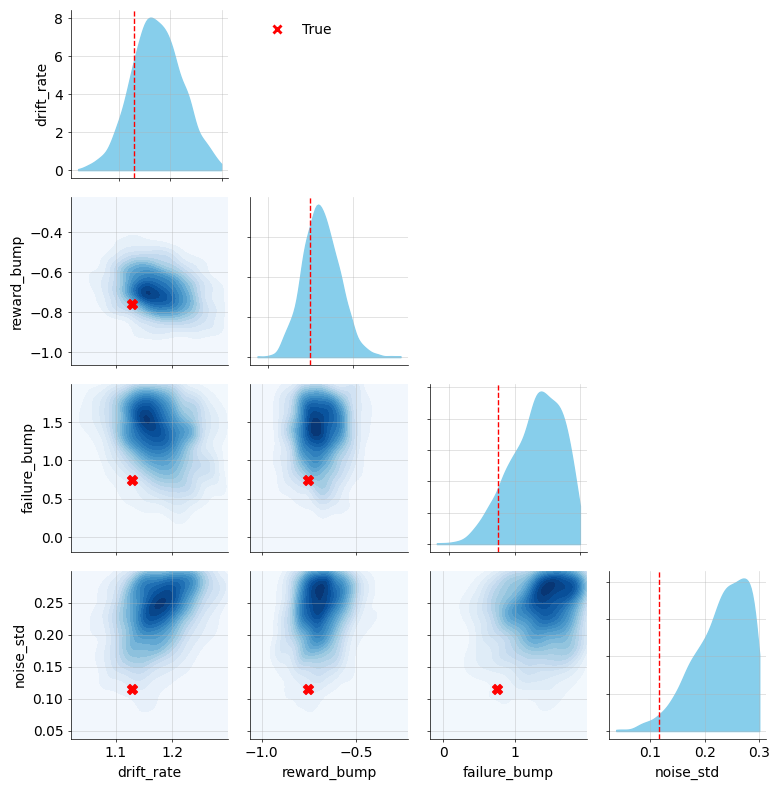

In [15]:
pairplot(posterior_samples, true_theta, param_names, figsize_per_param=2.0)

Running SBC with 100 tests...
  0/100...

Normalizing observed statistics...

Running MCMC inference...
Posterior dataset variables: ['theta']
Posterior theta shape (chain, draw, n_params): (2, 400, 4)
Posterior samples shape (flattened): (800, 4)

Normalizing observed statistics...

Running MCMC inference...
Posterior dataset variables: ['theta']
Posterior theta shape (chain, draw, n_params): (2, 400, 4)
Posterior samples shape (flattened): (800, 4)

Normalizing observed statistics...

Running MCMC inference...
Posterior dataset variables: ['theta']
Posterior theta shape (chain, draw, n_params): (2, 400, 4)
Posterior samples shape (flattened): (800, 4)

Normalizing observed statistics...

Running MCMC inference...
Posterior dataset variables: ['theta']
Posterior theta shape (chain, draw, n_params): (2, 400, 4)
Posterior samples shape (flattened): (800, 4)

Normalizing observed statistics...

Running MCMC inference...
Posterior dataset variables: ['theta']
Posterior theta shape (chain,

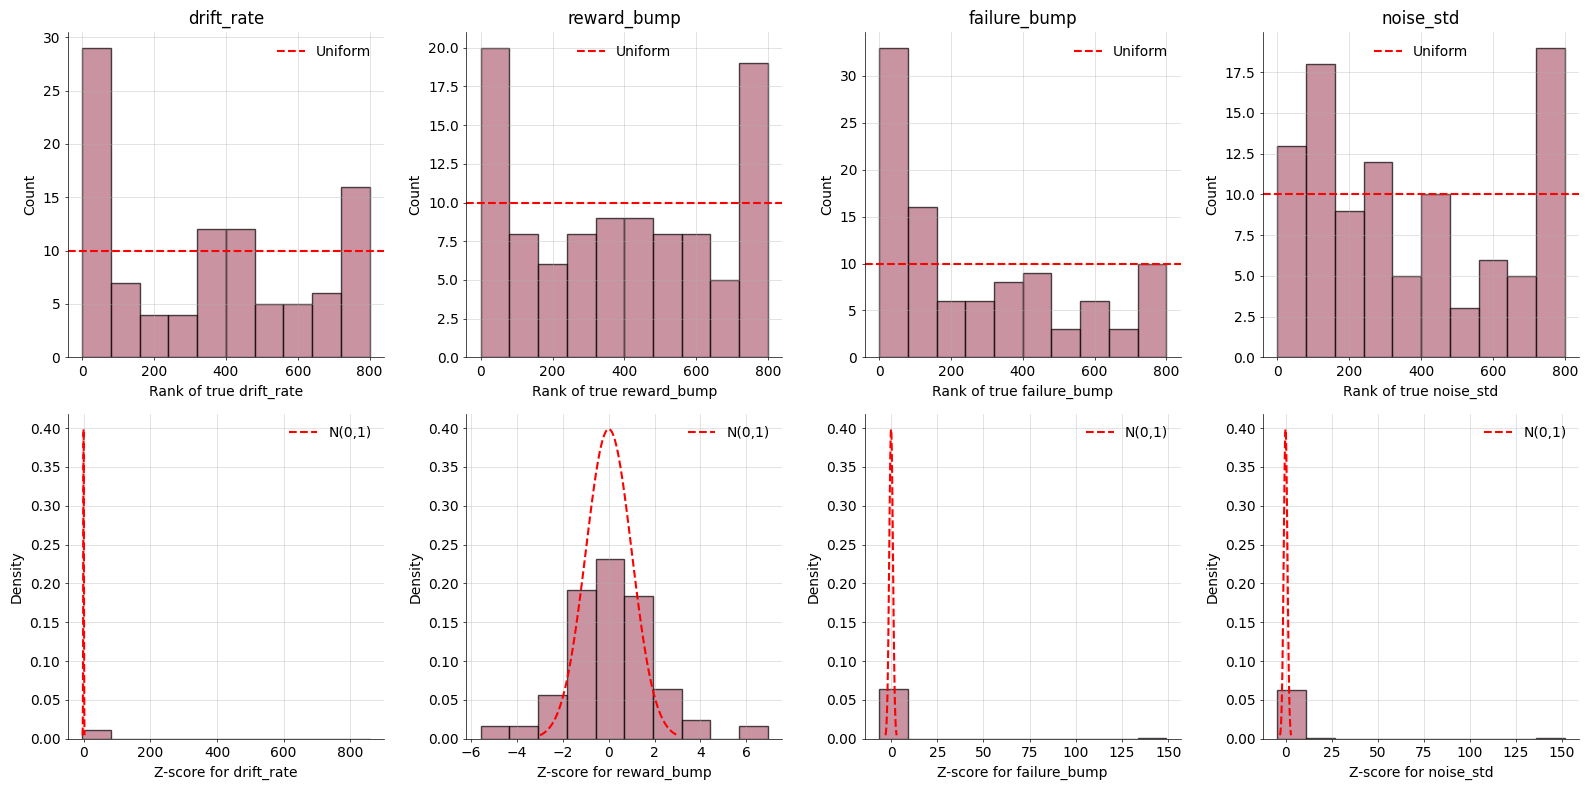


SBC EVALUATION SUMMARY

drift_rate:
  Z-score: 9.162 ± 85.351 (expect 0 ± 1)
  KS test: p=0.000 (>0.05 is good)
  ⚠️  Biased: posterior mean is off by 9.16 std devs
  ⚠️  Miscalibrated: posterior width is too wide
  ⚠️  Rank distribution not uniform

reward_bump:
  Z-score: 0.124 ± 1.885 (expect 0 ± 1)
  KS test: p=0.000 (>0.05 is good)
  ⚠️  Miscalibrated: posterior width is too wide
  ⚠️  Rank distribution not uniform

failure_bump:
  Z-score: 2.176 ± 14.895 (expect 0 ± 1)
  KS test: p=0.000 (>0.05 is good)
  ⚠️  Biased: posterior mean is off by 2.18 std devs
  ⚠️  Miscalibrated: posterior width is too wide
  ⚠️  Rank distribution not uniform

noise_std:
  Z-score: 1.760 ± 15.208 (expect 0 ± 1)
  KS test: p=0.000 (>0.05 is good)
  ⚠️  Biased: posterior mean is off by 1.76 std devs
  ⚠️  Miscalibrated: posterior width is too wide
  ⚠️  Rank distribution not uniform


In [16]:
def run_sbc_evaluation(snle, snle_params, y_mean, y_std, simulator, prior_fn, n_tests=100):
    """
    Run SBC to check if posterior captures true parameters correctly
    """
    from jax import random
    import jax.numpy as jnp
    import matplotlib.pyplot as plt
    
    rng_key = random.PRNGKey(42)
    param_names = ['drift_rate', 'reward_bump', 'failure_bump', 'noise_std']
    
    ranks = {param: [] for param in param_names}
    z_scores = {param: [] for param in param_names}
    bins = 10
    
    print(f"Running SBC with {n_tests} tests...")
    
    for test in range(n_tests):
        if test % 20 == 0:
            print(f"  {test}/{n_tests}...")
            
        rng_key, subkey1, subkey2 = random.split(rng_key, 3)
        
        # 1. Sample true parameters from prior
        true_theta = prior_fn().sample(seed=subkey1)['theta']
        
        # 2. Simulate data from true parameters
        _, observed_stats = simulator.simulate_one_window(true_theta, subkey2)
        
        # 3. Infer posterior
        rng_key, subkey3 = random.split(rng_key)
        posterior_samples, _ = infer_parameters_snle(
            snle, snle_params, observed_stats, y_mean, y_std,
            num_samples=500, num_warmup=100, num_chains=2, rng_key=subkey3
        )
        
        # 4. Compute ranks and z-scores
        for i, param in enumerate(param_names):
            rank = jnp.sum(posterior_samples[:, i] < true_theta[i])
            ranks[param].append(rank)
            
            # Z-score: how many std devs is true value from posterior mean?
            post_mean = posterior_samples[:, i].mean()
            post_std = posterior_samples[:, i].std()
            z = (post_mean - true_theta[i]) / post_std
            z_scores[param].append(z)
    
    # === PLOT SBC RESULTS ===
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    
    for i, param in enumerate(param_names):
        # Rank histogram (top row)
        ax_rank = axes[0, i]
        ax_rank.hist(ranks[param], bins=bins, alpha=0.7, edgecolor='k')
        ax_rank.axhline(n_tests/bins, color='r', linestyle='--', label='Uniform')
        ax_rank.set_xlabel(f'Rank of true {param}')
        ax_rank.set_ylabel('Count')
        ax_rank.set_title(param)
        ax_rank.legend()
        
        # Z-score histogram (bottom row)
        ax_z = axes[1, i]
        ax_z.hist(z_scores[param], bins=bins, alpha=0.7, edgecolor='k', density=True)
        
        # Overlay N(0,1) reference
        import numpy as np
        from scipy.stats import norm
        x = np.linspace(-3, 3, 100)
        ax_z.plot(x, norm.pdf(x), 'r--', label='N(0,1)')
        ax_z.set_xlabel(f'Z-score for {param}')
        ax_z.set_ylabel('Density')
        ax_z.legend()
    
    plt.tight_layout()
    plt.savefig('sbc_evaluation.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # === PRINT SUMMARY ===
    print("\n" + "="*70)
    print("SBC EVALUATION SUMMARY")
    print("="*70)
    
    for param in param_names:
        z_mean = jnp.mean(jnp.array(z_scores[param]))
        z_std = jnp.std(jnp.array(z_scores[param]))
        
        # Check uniformity with Kolmogorov-Smirnov test
        from scipy.stats import kstest
        ks_stat, ks_pval = kstest(ranks[param], 'uniform', args=(0, 500))
        
        print(f"\n{param}:")
        print(f"  Z-score: {z_mean:.3f} ± {z_std:.3f} (expect 0 ± 1)")
        print(f"  KS test: p={ks_pval:.3f} (>0.05 is good)")
        
        if abs(z_mean) > 0.3:
            print(f"  ⚠️  Biased: posterior mean is off by {z_mean:.2f} std devs")
        if z_std < 0.8 or z_std > 1.2:
            print(f"  ⚠️  Miscalibrated: posterior width is {'too narrow' if z_std < 1 else 'too wide'}")
        if ks_pval < 0.05:
            print(f"  ⚠️  Rank distribution not uniform")
        
        if abs(z_mean) < 0.3 and 0.8 < z_std < 1.2 and ks_pval > 0.05:
            print(f"  ✅ Well-calibrated!")
    
    return ranks, z_scores

# Run SBC
ranks, z_scores = run_sbc_evaluation(snle, snle_params, y_mean, y_std, simulator, prior_fn, n_tests=100)

Running SBC with 100 tests...
  0/100...

Normalizing observed statistics...

Running MCMC inference...
Posterior dataset variables: ['theta']
Posterior theta shape (chain, draw, n_params): (2, 400, 4)
Posterior samples shape (flattened): (800, 4)

Normalizing observed statistics...

Running MCMC inference...
Posterior dataset variables: ['theta']
Posterior theta shape (chain, draw, n_params): (2, 400, 4)
Posterior samples shape (flattened): (800, 4)

Normalizing observed statistics...

Running MCMC inference...
Posterior dataset variables: ['theta']
Posterior theta shape (chain, draw, n_params): (2, 400, 4)
Posterior samples shape (flattened): (800, 4)

Normalizing observed statistics...

Running MCMC inference...
Posterior dataset variables: ['theta']
Posterior theta shape (chain, draw, n_params): (2, 400, 4)
Posterior samples shape (flattened): (800, 4)

Normalizing observed statistics...

Running MCMC inference...
Posterior dataset variables: ['theta']
Posterior theta shape (chain,

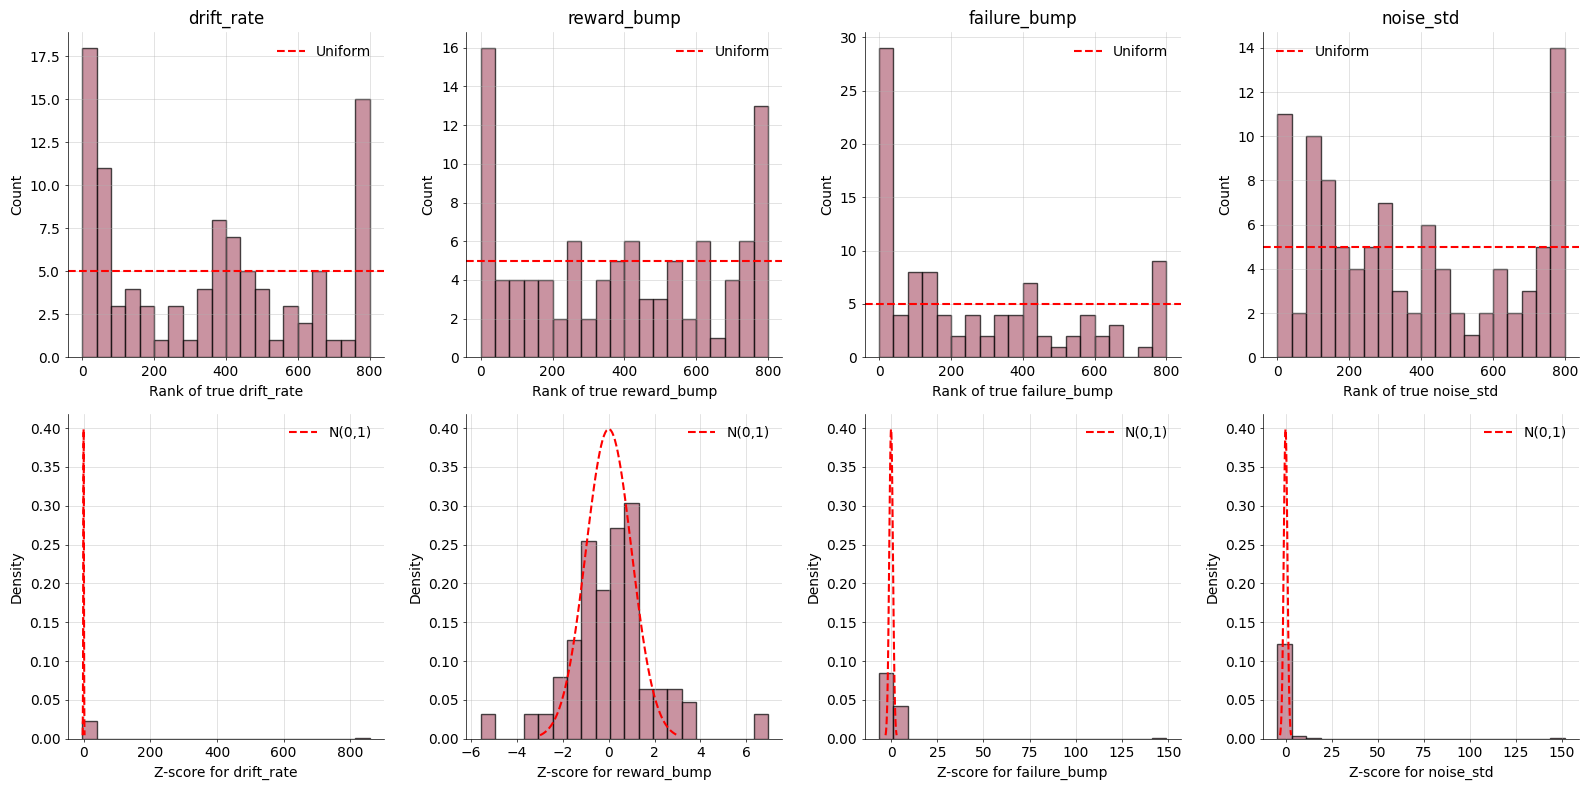


SBC EVALUATION SUMMARY

drift_rate:
  Z-score: 9.162 ± 85.351 (expect 0 ± 1)
  KS test: p=0.000 (>0.05 is good)
  ⚠️  Biased: posterior mean is off by 9.16 std devs
  ⚠️  Miscalibrated: posterior width is too wide
  ⚠️  Rank distribution not uniform

reward_bump:
  Z-score: 0.124 ± 1.885 (expect 0 ± 1)
  KS test: p=0.000 (>0.05 is good)
  ⚠️  Miscalibrated: posterior width is too wide
  ⚠️  Rank distribution not uniform

failure_bump:
  Z-score: 2.176 ± 14.895 (expect 0 ± 1)
  KS test: p=0.000 (>0.05 is good)
  ⚠️  Biased: posterior mean is off by 2.18 std devs
  ⚠️  Miscalibrated: posterior width is too wide
  ⚠️  Rank distribution not uniform

noise_std:
  Z-score: 1.760 ± 15.208 (expect 0 ± 1)
  KS test: p=0.000 (>0.05 is good)
  ⚠️  Biased: posterior mean is off by 1.76 std devs
  ⚠️  Miscalibrated: posterior width is too wide
  ⚠️  Rank distribution not uniform


In [17]:
def run_sbc_evaluation(snle, snle_params, y_mean, y_std, simulator, prior_fn, n_tests=100):
    """
    Run SBC to check if posterior captures true parameters correctly
    """
    from jax import random
    import jax.numpy as jnp
    import matplotlib.pyplot as plt
    
    rng_key = random.PRNGKey(42)
    param_names = ['drift_rate', 'reward_bump', 'failure_bump', 'noise_std']
    
    ranks = {param: [] for param in param_names}
    z_scores = {param: [] for param in param_names}
    
    print(f"Running SBC with {n_tests} tests...")
    
    for test in range(n_tests):
        if test % 20 == 0:
            print(f"  {test}/{n_tests}...")
            
        rng_key, subkey1, subkey2 = random.split(rng_key, 3)
        
        # 1. Sample true parameters from prior
        true_theta = prior_fn().sample(seed=subkey1)['theta']
        
        # 2. Simulate data from true parameters
        _, observed_stats = simulator.simulate_one_window(true_theta, subkey2)
        
        # 3. Infer posterior
        rng_key, subkey3 = random.split(rng_key)
        posterior_samples, _ = infer_parameters_snle(
            snle, snle_params, observed_stats, y_mean, y_std,
            num_samples=500, num_warmup=100, num_chains=2, rng_key=subkey3
        )
        
        # 4. Compute ranks and z-scores
        for i, param in enumerate(param_names):
            rank = jnp.sum(posterior_samples[:, i] < true_theta[i])
            ranks[param].append(rank)
            
            # Z-score: how many std devs is true value from posterior mean?
            post_mean = posterior_samples[:, i].mean()
            post_std = posterior_samples[:, i].std()
            z = (post_mean - true_theta[i]) / post_std
            z_scores[param].append(z)
    
    # === PLOT SBC RESULTS ===
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    
    for i, param in enumerate(param_names):
        # Rank histogram (top row)
        ax_rank = axes[0, i]
        ax_rank.hist(ranks[param], bins=20, alpha=0.7, edgecolor='k')
        ax_rank.axhline(n_tests/20, color='r', linestyle='--', label='Uniform')
        ax_rank.set_xlabel(f'Rank of true {param}')
        ax_rank.set_ylabel('Count')
        ax_rank.set_title(param)
        ax_rank.legend()
        
        # Z-score histogram (bottom row)
        ax_z = axes[1, i]
        ax_z.hist(z_scores[param], bins=20, alpha=0.7, edgecolor='k', density=True)
        
        # Overlay N(0,1) reference
        import numpy as np
        from scipy.stats import norm
        x = np.linspace(-3, 3, 100)
        ax_z.plot(x, norm.pdf(x), 'r--', label='N(0,1)')
        ax_z.set_xlabel(f'Z-score for {param}')
        ax_z.set_ylabel('Density')
        ax_z.legend()
    
    plt.tight_layout()
    plt.savefig('sbc_evaluation.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # === PRINT SUMMARY ===
    print("\n" + "="*70)
    print("SBC EVALUATION SUMMARY")
    print("="*70)
    
    for param in param_names:
        z_mean = jnp.mean(jnp.array(z_scores[param]))
        z_std = jnp.std(jnp.array(z_scores[param]))
        
        # Check uniformity with Kolmogorov-Smirnov test
        from scipy.stats import kstest
        ks_stat, ks_pval = kstest(ranks[param], 'uniform', args=(0, 500))
        
        print(f"\n{param}:")
        print(f"  Z-score: {z_mean:.3f} ± {z_std:.3f} (expect 0 ± 1)")
        print(f"  KS test: p={ks_pval:.3f} (>0.05 is good)")
        
        if abs(z_mean) > 0.3:
            print(f"  ⚠️  Biased: posterior mean is off by {z_mean:.2f} std devs")
        if z_std < 0.8 or z_std > 1.2:
            print(f"  ⚠️  Miscalibrated: posterior width is {'too narrow' if z_std < 1 else 'too wide'}")
        if ks_pval < 0.05:
            print(f"  ⚠️  Rank distribution not uniform")
        
        if abs(z_mean) < 0.3 and 0.8 < z_std < 1.2 and ks_pval > 0.05:
            print(f"  ✅ Well-calibrated!")
    
    return ranks, z_scores

# Run SBC
ranks, z_scores = run_sbc_evaluation(snle, snle_params, y_mean, y_std, simulator, prior_fn, n_tests=100)

Running parameter recovery tests...

low_drift: [0.2 1.  1.  0.2]

Normalizing observed statistics...

Running MCMC inference...
Posterior dataset variables: ['theta']
Posterior theta shape (chain, draw, n_params): (2, 800, 4)
Posterior samples shape (flattened): (1600, 4)
  Recovery:
    drift_rate: true=0.200, est=0.595±0.297, 95%CI=[0.112, 0.879] ✓
    reward_bump: true=1.000, est=0.686±0.170, 95%CI=[0.441, 1.159] ✓
    failure_bump: true=1.000, est=0.729±0.622, 95%CI=[-0.200, 1.334] ✓
    noise_std: true=0.200, est=0.247±0.069, 95%CI=[0.083, 0.300] ✓

mid_drift: [1.  1.  1.  0.2]

Normalizing observed statistics...

Running MCMC inference...
Posterior dataset variables: ['theta']
Posterior theta shape (chain, draw, n_params): (2, 800, 4)
Posterior samples shape (flattened): (1600, 4)
  Recovery:
    drift_rate: true=1.000, est=1.052±0.029, 95%CI=[0.997, 1.110] ✓
    reward_bump: true=1.000, est=0.245±0.226, 95%CI=[-0.157, 0.764] ✗
    failure_bump: true=1.000, est=1.248±0.429, 95%C

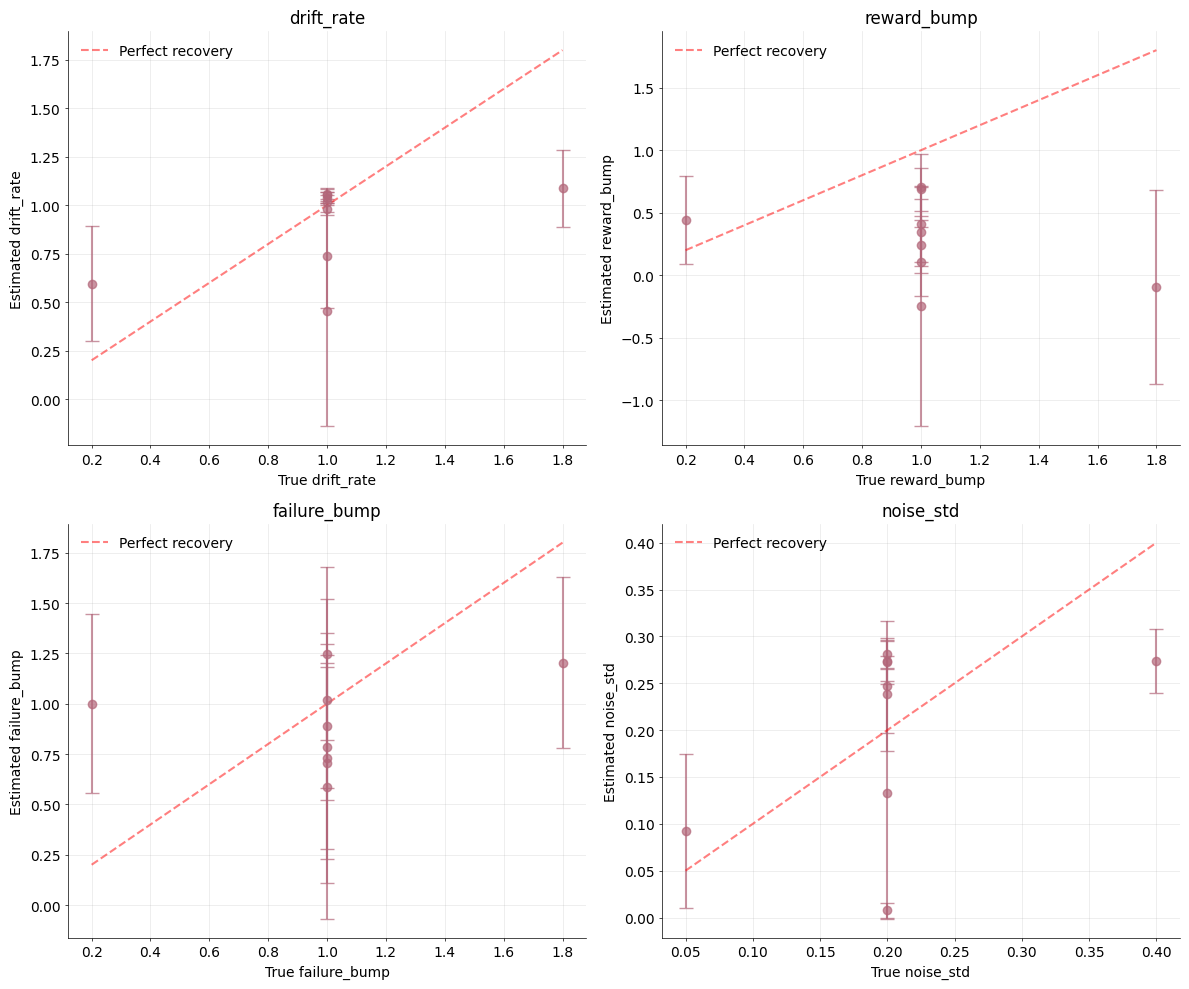


PARAMETER RECOVERY SUMMARY
drift_rate: 78% coverage (expect ~95%)
  ⚠️  Low coverage - posterior too narrow or biased
reward_bump: 33% coverage (expect ~95%)
  ⚠️  Low coverage - posterior too narrow or biased
failure_bump: 100% coverage (expect ~95%)
  ⚠️  High coverage - posterior may be too wide
noise_std: 44% coverage (expect ~95%)
  ⚠️  Low coverage - posterior too narrow or biased


In [18]:
def parameter_recovery_test(snle, snle_params, y_mean, y_std, simulator, prior_fn):
    """
    Test parameter recovery at different points in parameter space
    """
    from jax import random
    import jax.numpy as jnp
    import matplotlib.pyplot as plt
    
    # Test cases spanning the prior
    test_cases = {
        'low_drift': jnp.array([0.2, 1.0, 1.0, 0.2]),
        'mid_drift': jnp.array([1.0, 1.0, 1.0, 0.2]),
        'high_drift': jnp.array([1.8, 1.0, 1.0, 0.2]),
        
        'low_reward': jnp.array([1.0, 0.2, 1.0, 0.2]),
        'high_reward': jnp.array([1.0, 1.8, 1.0, 0.2]),
        
        'low_failure': jnp.array([1.0, 1.0, 0.2, 0.2]),
        'high_failure': jnp.array([1.0, 1.0, 1.8, 0.2]),
        
        'low_noise': jnp.array([1.0, 1.0, 1.0, 0.05]),
        'high_noise': jnp.array([1.0, 1.0, 1.0, 0.4]),
    }
    
    rng_key = random.PRNGKey(123)
    param_names = ['drift_rate', 'reward_bump', 'failure_bump', 'noise_std']
    
    results = []
    
    print("Running parameter recovery tests...")
    
    for name, true_theta in test_cases.items():
        print(f"\n{name}: {true_theta}")
        
        rng_key, subkey1, subkey2 = random.split(rng_key, 3)
        
        # Simulate
        _, observed_stats = simulator.simulate_one_window(true_theta, subkey1)
        
        # Infer
        from aind_behavior_vrforaging_analysis.sbi_ddm_analysis.snle.snle_inference_jax import infer_parameters_snle
        
        posterior_samples, _ = infer_parameters_snle(
            snle, snle_params, observed_stats, y_mean, y_std,
            num_samples=1000, num_warmup=200, num_chains=2, rng_key=subkey2
        )
        
        # Analyze
        post_mean = posterior_samples.mean(axis=0)
        post_std = posterior_samples.std(axis=0)
        
        # Coverage: is true value in 95% credible interval?
        ci_lower = jnp.percentile(posterior_samples, 2.5, axis=0)
        ci_upper = jnp.percentile(posterior_samples, 97.5, axis=0)
        in_ci = (true_theta >= ci_lower) & (true_theta <= ci_upper)
        
        results.append({
            'name': name,
            'true': true_theta,
            'mean': post_mean,
            'std': post_std,
            'ci_lower': ci_lower,
            'ci_upper': ci_upper,
            'in_ci': in_ci,
        })
        
        print(f"  Recovery:")
        for i, param in enumerate(param_names):
            coverage = "✓" if in_ci[i] else "✗"
            print(f"    {param}: true={true_theta[i]:.3f}, "
                  f"est={post_mean[i]:.3f}±{post_std[i]:.3f}, "
                  f"95%CI=[{ci_lower[i]:.3f}, {ci_upper[i]:.3f}] {coverage}")
    
    # === PLOT RECOVERY ===
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    for i, (ax, param) in enumerate(zip(axes.flat, param_names)):
        true_vals = [r['true'][i] for r in results]
        est_vals = [r['mean'][i] for r in results]
        est_stds = [r['std'][i] for r in results]
        
        # Plot true vs estimated
        ax.errorbar(true_vals, est_vals, yerr=est_stds, fmt='o', capsize=5, alpha=0.7)
        
        # Identity line
        lims = [min(true_vals), max(true_vals)]
        ax.plot(lims, lims, 'r--', alpha=0.5, label='Perfect recovery')
        
        ax.set_xlabel(f'True {param}')
        ax.set_ylabel(f'Estimated {param}')
        ax.set_title(param)
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('parameter_recovery.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Summary
    print("\n" + "="*70)
    print("PARAMETER RECOVERY SUMMARY")
    print("="*70)
    
    for i, param in enumerate(param_names):
        coverage = sum(r['in_ci'][i] for r in results) / len(results) * 100
        print(f"{param}: {coverage:.0f}% coverage (expect ~95%)")
        
        if coverage < 85:
            print(f"  ⚠️  Low coverage - posterior too narrow or biased")
        elif coverage > 98:
            print(f"  ⚠️  High coverage - posterior may be too wide")
        else:
            print(f"  ✅ Good coverage!")
    
    return results

# Run recovery test
recovery_results = parameter_recovery_test(snle, snle_params, y_mean, y_std, simulator, prior_fn)


Normalizing observed statistics...

Running MCMC inference...
Posterior dataset variables: ['theta']
Posterior theta shape (chain, draw, n_params): (2, 400, 4)
Posterior samples shape (flattened): (800, 4)
Generating posterior predictive samples...


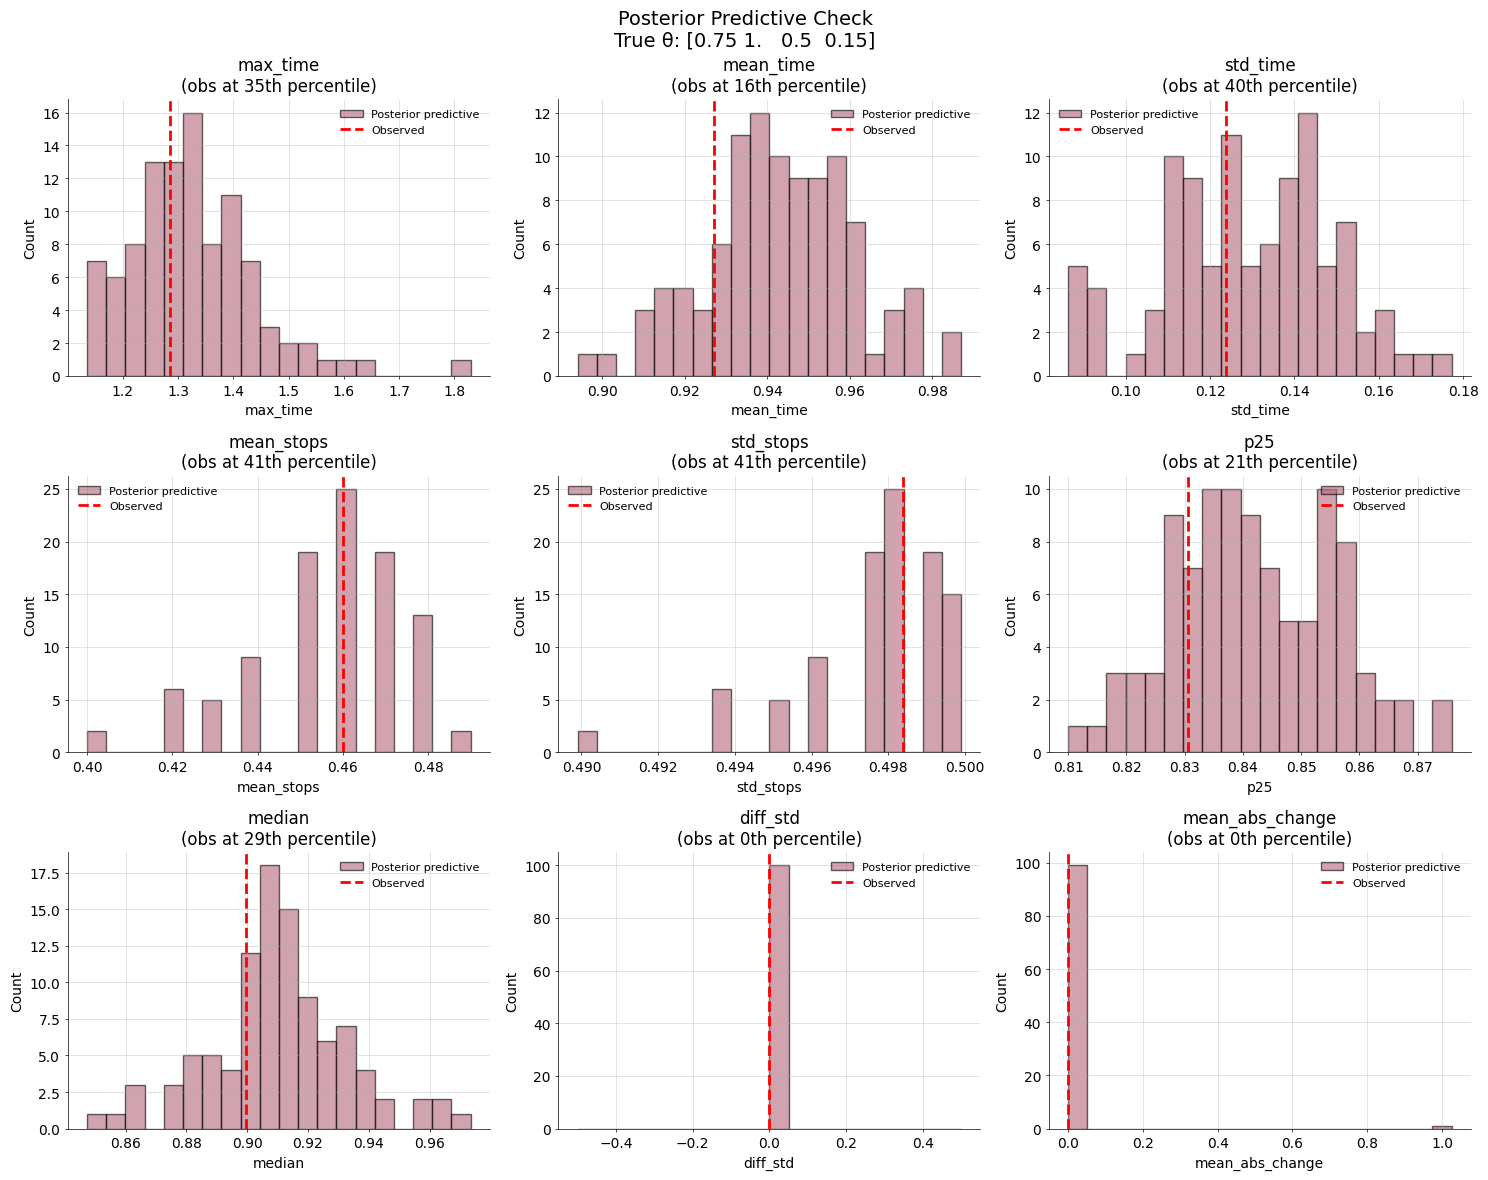


✓ Coverage: 100.0% of features within posterior predictive range
✅ Good coverage!


In [19]:
def posterior_predictive_check(snle, snle_params, y_mean, y_std, simulator, true_theta):
    """
    Generate data from true params, infer, then check if we can reproduce data
    """
    from jax import random
    import jax.numpy as jnp
    import matplotlib.pyplot as plt
    
    rng_key = random.PRNGKey(456)
    
    # 1. Generate observed data
    rng_key, subkey = random.split(rng_key)
    _, observed_stats = simulator.simulate_one_window(true_theta, subkey)
    
    # 2. Infer posterior
    from aind_behavior_vrforaging_analysis.sbi_ddm_analysis.snle.snle_inference_jax import infer_parameters_snle
    
    rng_key, subkey = random.split(rng_key)
    posterior_samples, _ = infer_parameters_snle(
        snle, snle_params, observed_stats, y_mean, y_std,
        num_samples=500, num_warmup=100, num_chains=2, rng_key=subkey
    )
    
    # 3. Generate posterior predictive samples
    print("Generating posterior predictive samples...")
    post_pred_stats = []
    
    for i in range(min(100, len(posterior_samples))):
        rng_key, subkey = random.split(rng_key)
        _, stats = simulator.simulate_one_window(posterior_samples[i], subkey)
        post_pred_stats.append(stats)
    
    post_pred_stats = jnp.array(post_pred_stats)
    

    # Select key features to plot
    key_features = [0, 1, 2, 3, 4, 16, 17, 21, 22]  # iqr, early_mean, etc.
    feature_names = [FEATURE_NAMES[i] for i in key_features]
    
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    
    for ax, feat_idx, name in zip(axes.flat, key_features, feature_names):
        # Posterior predictive distribution
        ax.hist(post_pred_stats[:, feat_idx], bins=20, alpha=0.6, 
                edgecolor='k', label='Posterior predictive')
        
        # Observed value
        ax.axvline(observed_stats[feat_idx], color='r', linestyle='--', 
                   linewidth=2, label='Observed')
        
        # Percentile
        percentile = (post_pred_stats[:, feat_idx] < observed_stats[feat_idx]).mean() * 100
        
        ax.set_xlabel(name)
        ax.set_ylabel('Count')
        ax.set_title(f'{name}\n(obs at {percentile:.0f}th percentile)')
        ax.legend(fontsize=8)
    
    plt.suptitle(f'Posterior Predictive Check\nTrue θ: {true_theta}', fontsize=14)
    plt.tight_layout()
    plt.savefig('posterior_predictive_check.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Check coverage
    in_range = ((post_pred_stats.min(axis=0) <= observed_stats) & 
                (observed_stats <= post_pred_stats.max(axis=0)))
    coverage = in_range.mean() * 100
    
    print(f"\n✓ Coverage: {coverage:.1f}% of features within posterior predictive range")
    
    if coverage < 80:
        print("⚠️  Warning: Low coverage - model may not fit data well")
    else:
        print("✅ Good coverage!")
    
    return post_pred_stats

# Run posterior predictive check
test_theta = jnp.array([0.75, 1.0, 0.5, 0.15])
post_pred = posterior_predictive_check(snle, snle_params, y_mean, y_std, simulator, test_theta)


Generating patches from posterior samples for comparison...

2. Simulating observed data...


arviz - WARNING - Shape validation failed: input_shape: (1, 300), minimum_shape: (chains=2, draws=4)


['max_time', 'mean_time', 'std_time', 'mean_stops', 'std_stops', 'mean_rewards', 'std_rewards', 'mean_time_after_reward', 'mean_time_after_failure', 'std_time_after_reward', 'std_time_after_failure', 'early_mean', 'late_mean', 'temporal_trend', 'late_minus_early', 'middle_mean', 'p25', 'median', 'p75', 'iqr', 'autocorr_lag1', 'diff_std', 'mean_abs_change', 'reward_rate', 'mean_reward_trial', 'prop_patches_with_reward', 'n_patches', 'mean_sites_per_patch', 'stop_rate']


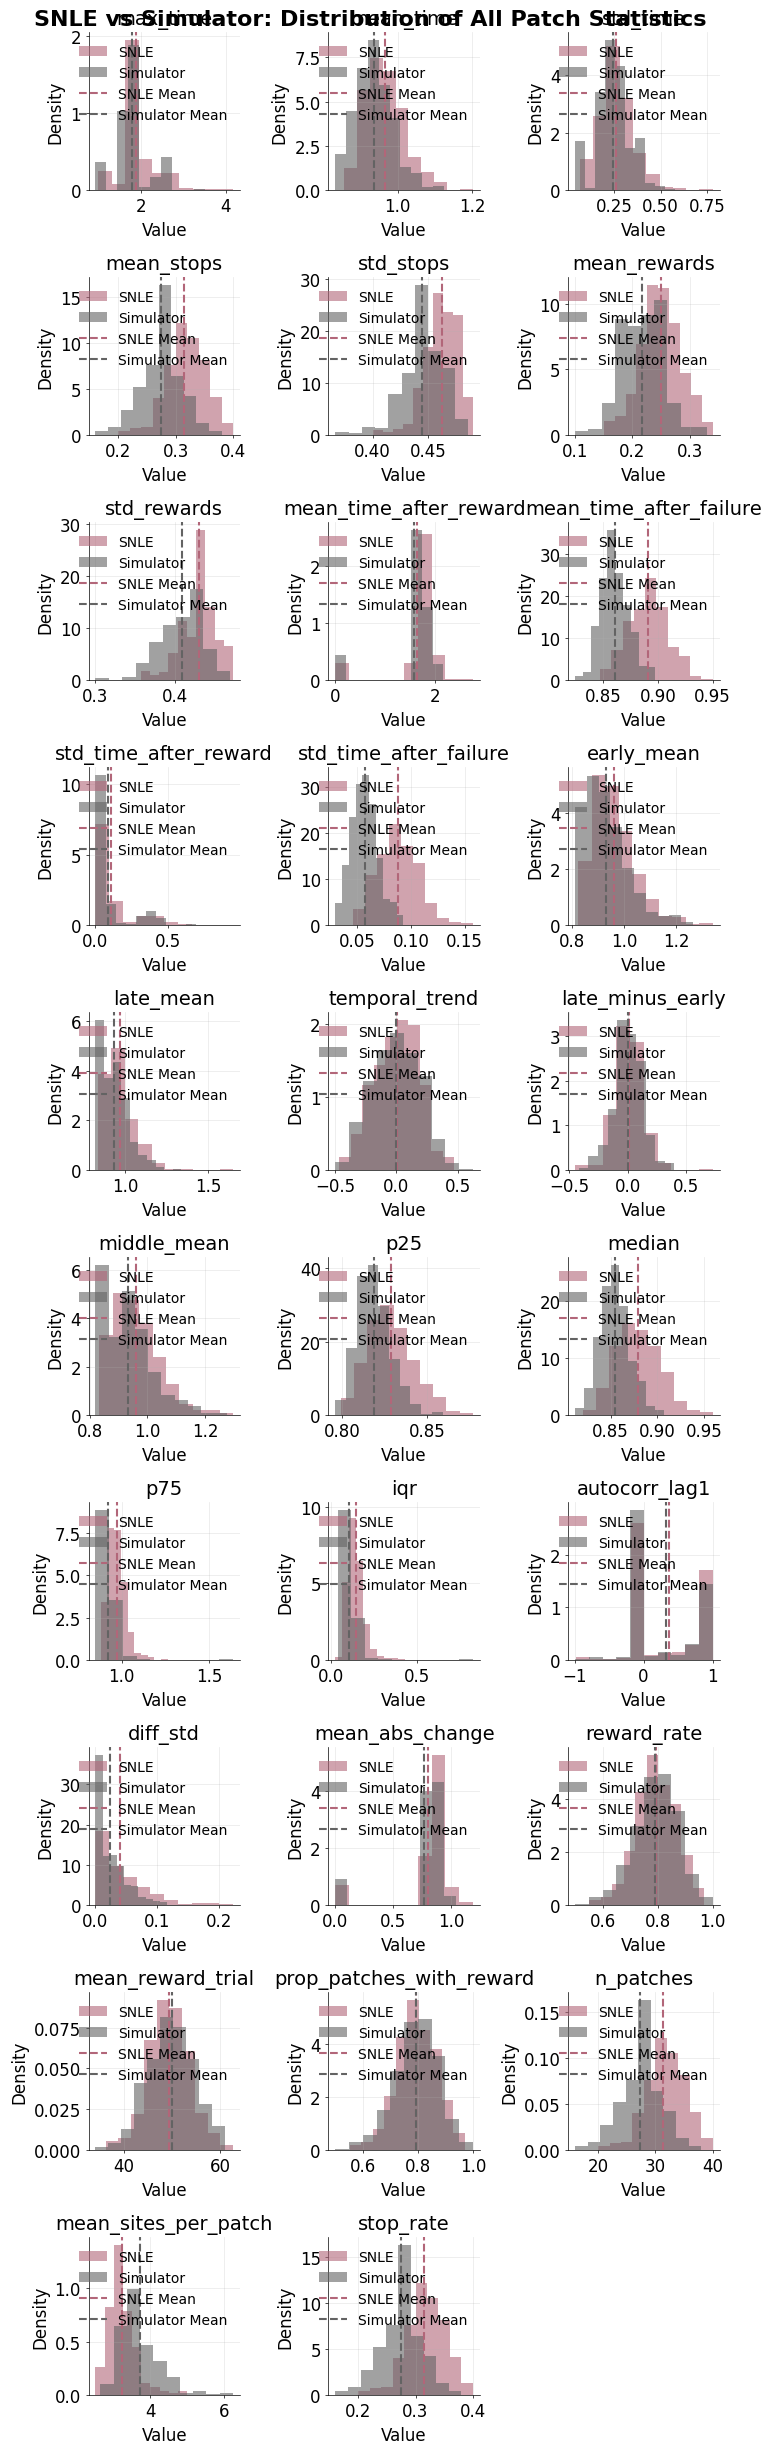


COMPARISON SUMMARY

max_time:
  SNLE:      1.895 ± 0.411
  Simulator: 1.796 ± 0.392

mean_time:
  SNLE:      0.967 ± 0.052
  Simulator: 0.937 ± 0.049

std_time:
  SNLE:      0.257 ± 0.093
  Simulator: 0.243 ± 0.093

mean_stops:
  SNLE:      0.314 ± 0.034
  Simulator: 0.274 ± 0.035

std_stops:
  SNLE:      0.463 ± 0.014
  Simulator: 0.444 ± 0.019

mean_rewards:
  SNLE:      0.250 ± 0.037
  Simulator: 0.217 ± 0.036

std_rewards:
  SNLE:      0.431 ± 0.022
  Simulator: 0.410 ± 0.026

mean_time_after_reward:
  SNLE:      1.643 ± 0.509
  Simulator: 1.576 ± 0.519

mean_time_after_failure:
  SNLE:      0.891 ± 0.018
  Simulator: 0.860 ± 0.012

std_time_after_reward:
  SNLE:      0.107 ± 0.144
  Simulator: 0.084 ± 0.130

std_time_after_failure:
  SNLE:      0.088 ± 0.018
  Simulator: 0.057 ± 0.012

early_mean:
  SNLE:      0.962 ± 0.081
  Simulator: 0.933 ± 0.082

late_mean:
  SNLE:      0.969 ± 0.092
  Simulator: 0.933 ± 0.083

temporal_trend:
  SNLE:      0.004 ± 0.176
  Simulator: -0.001 ±

In [20]:
# Generate multiple patches from posterior samples to compare distributions
print("\nGenerating patches from posterior samples for comparison...")

num_window_sites = 500

#--- Simulate 'real' data from simulator---
print("\n2. Simulating observed data...")
real_data = []
for i_site in range(num_window_sites):
    rng_key, subkey = random.split(rng_key)
    _, data = simulator.simulate_one_window(true_theta, subkey)
    real_data.append(data)
real_data = np.array(real_data)

# # 2. Generate "synthetic" data from simulator using posterior-sampled parameters
# Get observed summary stats
rng_key, subkey = random.split(rng_key)
_, observed_stats = simulator.simulate_one_window(true_theta, subkey)
obs_norm = (observed_stats - y_mean) / y_std

# Sample posterior θ using ONE observation
rng_key, sub = random.split(rng_key)
inference_results, diagnostics = snle.sample_posterior(
    sub, snle_params,
    observable=obs_norm,
    n_samples=500,
    n_chains=1,
    n_warmup=200,
)

posterior_ds = extract_samples(inference_results)
theta_samples = posterior_ds["theta"].values.reshape(-1, 4)  # shape (500,4)

# Simulate synthetic patches for comparison
posterior_mean_theta = theta_samples.mean(axis=0)  # Single point estimate

synthetic_data = []
for i in range(500):
    rng_key, subkey = random.split(rng_key)
    _, data = simulator.simulate_one_window(posterior_mean_theta, subkey)
    synthetic_data.append(data)
synthetic_data = jnp.array(synthetic_data)

# 4. Plot
plot_real_synth_hist(real_data, synthetic_data)



In [21]:
print("True parameters:")
print(f"  drift_rate: {true_theta[0]:.3f}")
print(f"  reward_bump: {true_theta[1]:.3f}")
print(f"  failure_bump: {true_theta[2]:.3f}")
print(f"  noise_std: {true_theta[3]:.3f}")

print("\nPosterior mean:")
posterior_mean = theta_samples.mean(axis=0)
print(f"  drift_rate: {posterior_mean[0]:.3f}")
print(f"  reward_bump: {posterior_mean[1]:.3f}")
print(f"  failure_bump: {posterior_mean[2]:.3f}")
print(f"  noise_std: {posterior_mean[3]:.3f}")

print("\nPosterior std:")
posterior_std = theta_samples.std(axis=0)
print(f"  drift_rate: {posterior_std[0]:.3f}")
print(f"  reward_bump: {posterior_std[1]:.3f}")
print(f"  failure_bump: {posterior_std[2]:.3f}")
print(f"  noise_std: {posterior_std[3]:.3f}")

# Compute Z-scores
z_scores = (posterior_mean - true_theta) / posterior_std
print("\nZ-scores (should be ~N(0,1) if well-calibrated):")
for i, param in enumerate(param_names):
    print(f"  {param}: {z_scores[i]:.2f}")

True parameters:
  drift_rate: 1.129
  reward_bump: -0.756
  failure_bump: 0.751
  noise_std: 0.116

Posterior mean:
  drift_rate: 1.091
  reward_bump: -0.557
  failure_bump: 1.367
  noise_std: 0.201

Posterior std:
  drift_rate: 0.038
  reward_bump: 0.092
  failure_bump: 0.469
  noise_std: 0.049

Z-scores (should be ~N(0,1) if well-calibrated):
  drift_rate: -1.01
  reward_bump: 2.17
  failure_bump: 1.31
  noise_std: 1.72


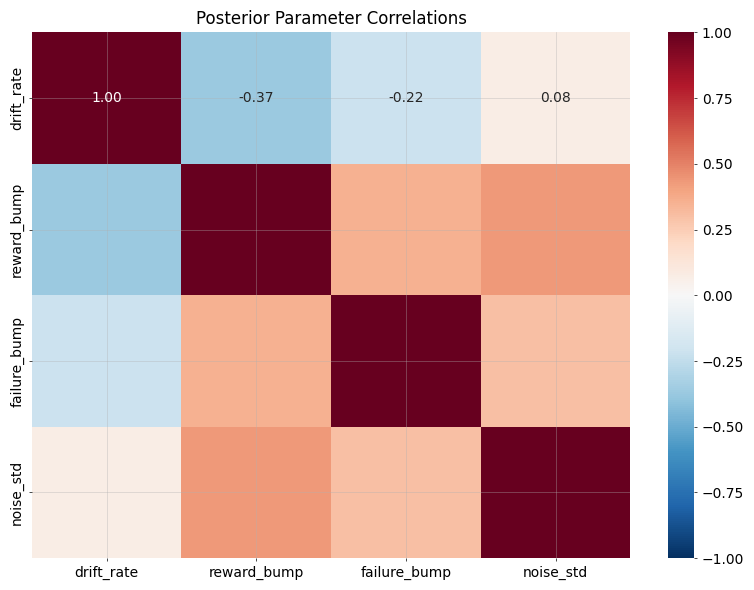

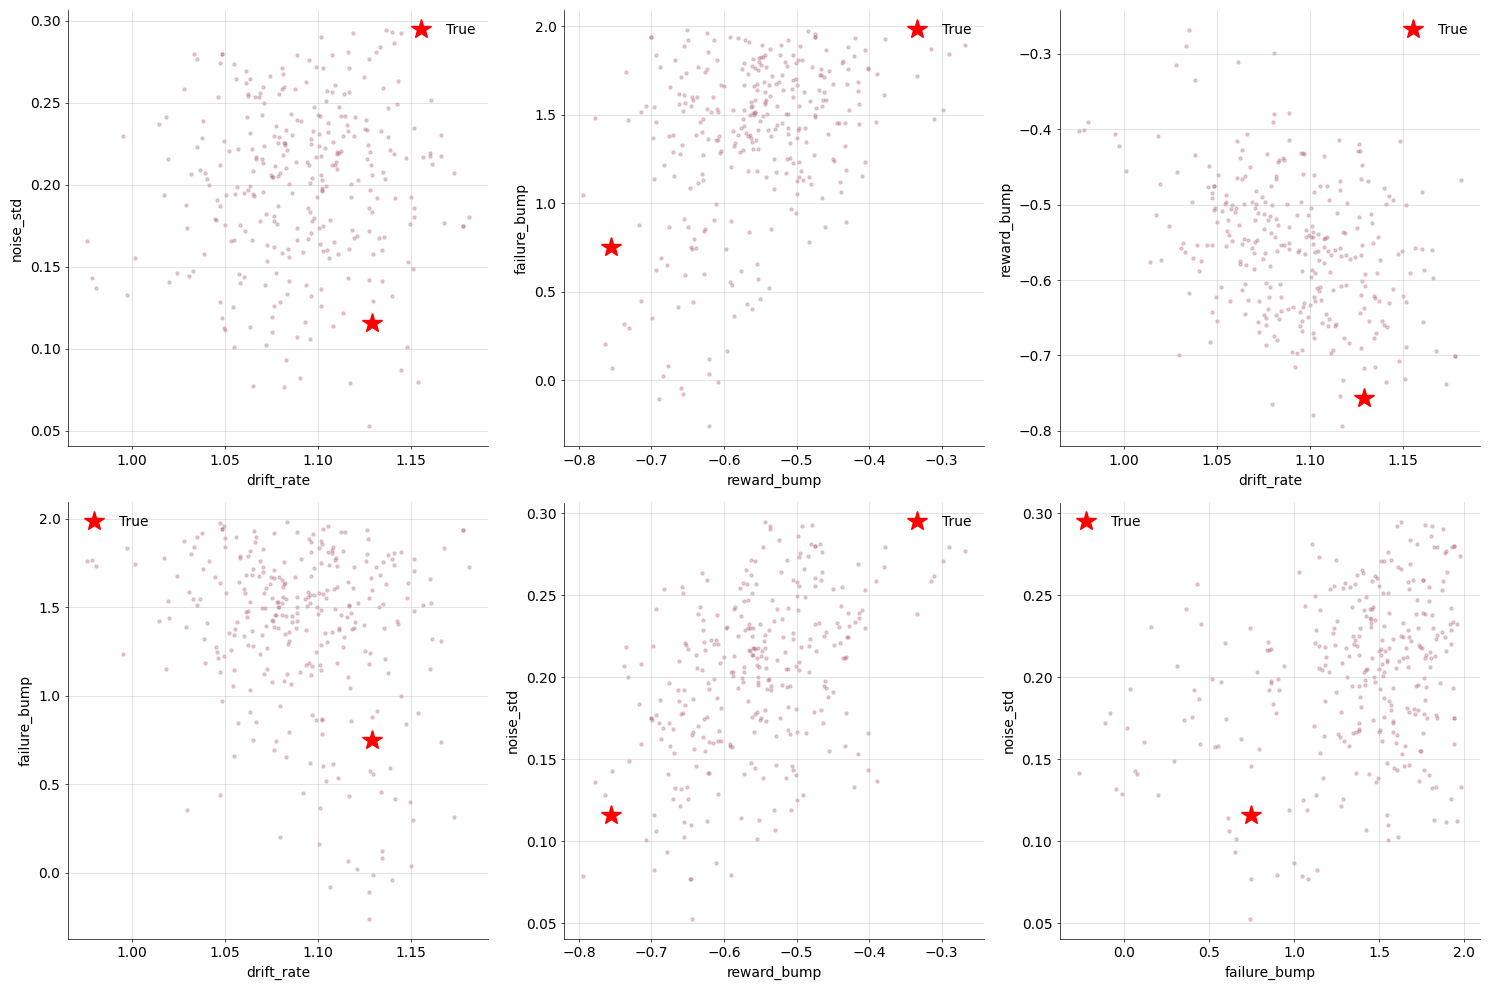

In [22]:
import seaborn as sns

# Correlation matrix of posterior samples
corr_matrix = np.corrcoef(theta_samples.T)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', 
            xticklabels=param_names, yticklabels=param_names,
            cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax)
plt.title('Posterior Parameter Correlations')
plt.tight_layout()
plt.show()

# Pairwise scatter plots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
pairs = [
    (0, 3, 'drift_rate', 'noise_std'),
    (1, 2, 'reward_bump', 'failure_bump'),
    (0, 1, 'drift_rate', 'reward_bump'),
    (0, 2, 'drift_rate', 'failure_bump'),
    (1, 3, 'reward_bump', 'noise_std'),
    (2, 3, 'failure_bump', 'noise_std'),
]

for ax, (i, j, name_i, name_j) in zip(axes.flat, pairs):
    ax.scatter(theta_samples[:, i], theta_samples[:, j], alpha=0.3, s=5)
    ax.plot(true_theta[i], true_theta[j], 'r*', markersize=15, label='True')
    ax.set_xlabel(name_i)
    ax.set_ylabel(name_j)
    ax.legend()
plt.tight_layout()
plt.show()

In [23]:
# Test recovery with different noise levels
test_cases = [
    jnp.array([0.75, 1.1, 0.9, 0.05]),  # Very low noise
    jnp.array([0.75, 1.1, 0.9, 0.1]),   # Low noise
    jnp.array([0.75, 1.1, 0.9, 0.3]),   # High noise
]

for test_theta in test_cases:
    print(f"\nTrue noise_std: {test_theta[3]:.3f}")
    
    # Simulate and infer
    rng_key, subkey1, subkey2 = random.split(rng_key, 3)
    _, y_obs = simulator.simulate_one_window(test_theta, subkey1)
    
    obs_norm = (y_obs - y_mean) / y_std
    inference_results, _ = snle.sample_posterior(
        subkey2, snle_params, observable=obs_norm,
        n_samples=500, n_chains=1, n_warmup=200
    )
    
    posterior_ds = extract_samples(inference_results)
    theta_post = posterior_ds["theta"].values.reshape(-1, 4)
    
    print(f"Inferred noise_std: {theta_post[:, 3].mean():.3f} ± {theta_post[:, 3].std():.3f}")
    print(f"Z-score: {(theta_post[:, 3].mean() - test_theta[3]) / theta_post[:, 3].std():.2f}")


True noise_std: 0.050
Inferred noise_std: 0.076 ± 0.033
Z-score: 0.77

True noise_std: 0.100
Inferred noise_std: 0.068 ± 0.044
Z-score: -0.72

True noise_std: 0.300
Inferred noise_std: 0.187 ± 0.055
Z-score: -2.04


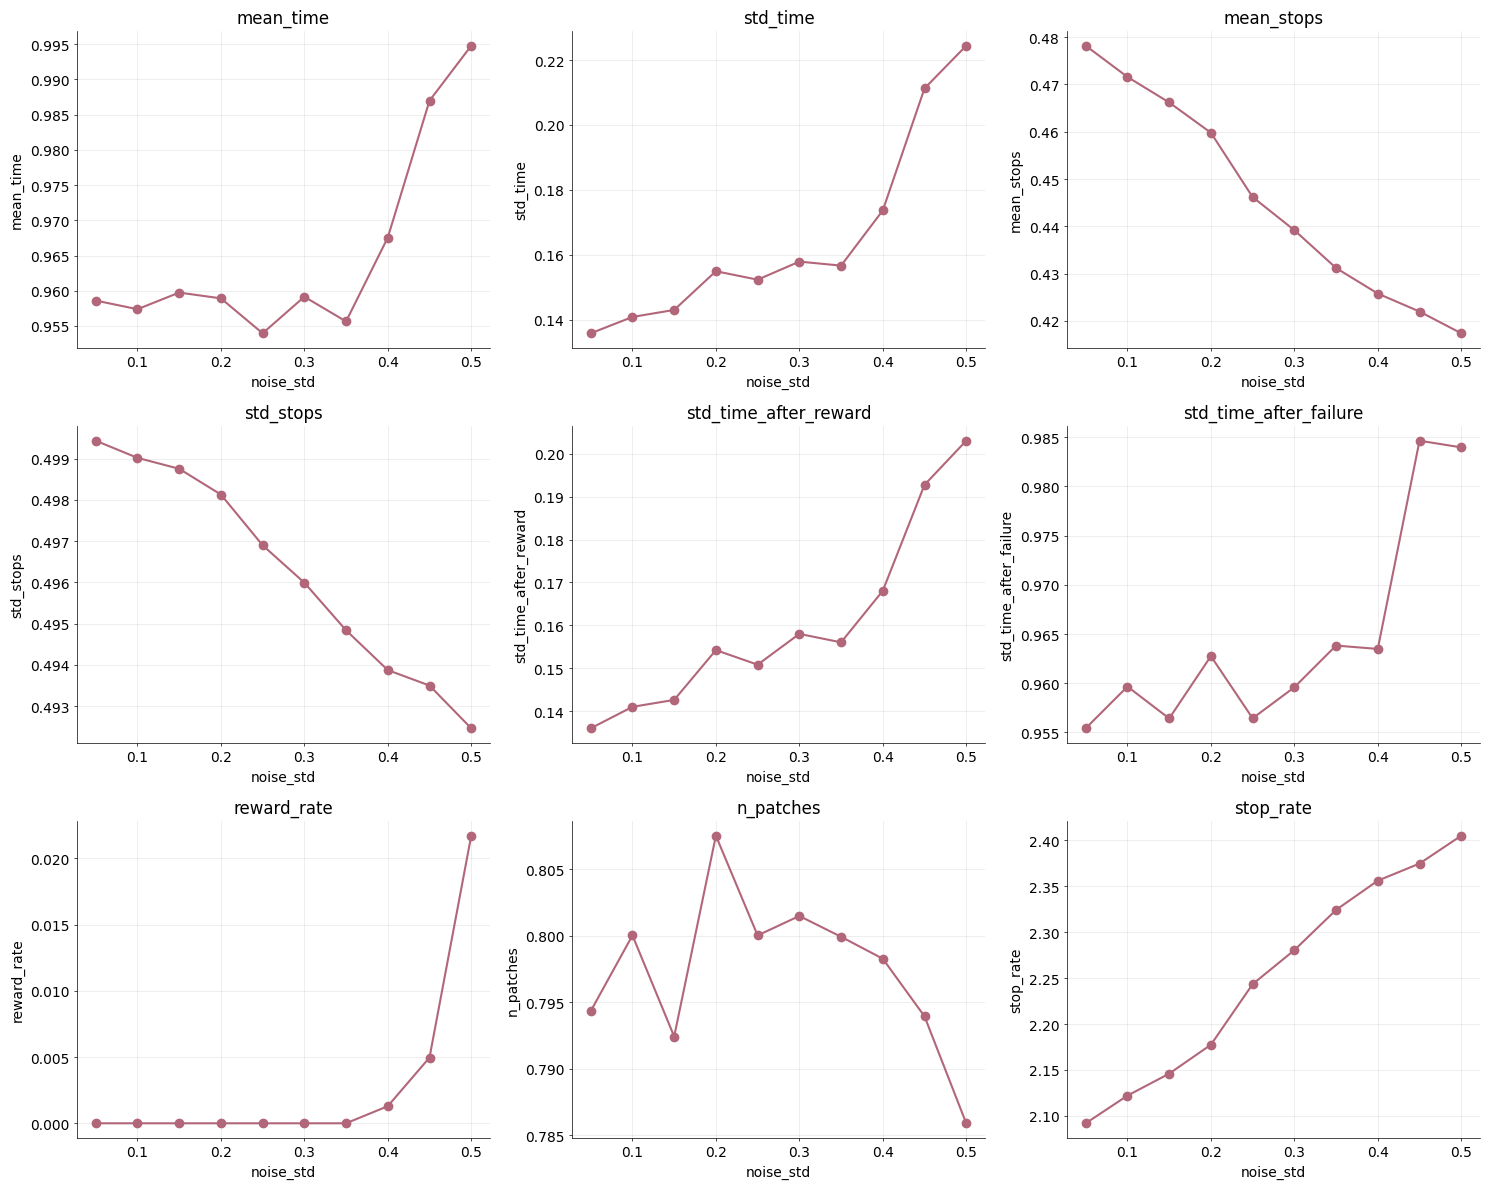

In [24]:
# Simulate with varying noise, see which stats are affected
noise_levels = jnp.linspace(0.05, 0.5, 10)
base_theta = jnp.array([0.75, 1.1, 0.9, 0.0])  # Will replace noise

stats_by_noise = []
for noise in noise_levels:
    theta = base_theta.at[3].set(noise)
    
    # Average over 50 simulations to reduce stochasticity
    stats_samples = []
    for _ in range(50):
        rng_key, subkey = random.split(rng_key)
        _, stats = simulator.simulate_one_window(theta, subkey)
        stats_samples.append(stats)
    
    mean_stats = jnp.mean(jnp.array(stats_samples), axis=0)
    stats_by_noise.append(mean_stats)

stats_by_noise = jnp.array(stats_by_noise)

# Plot: Which stats change with noise?
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
stat_indices = [1, 2, 3, 4, 10, 11, 21, 25, 27]  # Key stats
stat_names = ['mean_time', 'std_time', 'mean_stops', 'std_stops', 
              'std_time_after_reward', 'std_time_after_failure',
              'reward_rate', 'n_patches', 'stop_rate']

for ax, stat_idx, name in zip(axes.flat, stat_indices, stat_names):
    ax.plot(noise_levels, stats_by_noise[:, stat_idx], 'o-')
    ax.set_xlabel('noise_std')
    ax.set_ylabel(name)
    ax.set_title(name)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

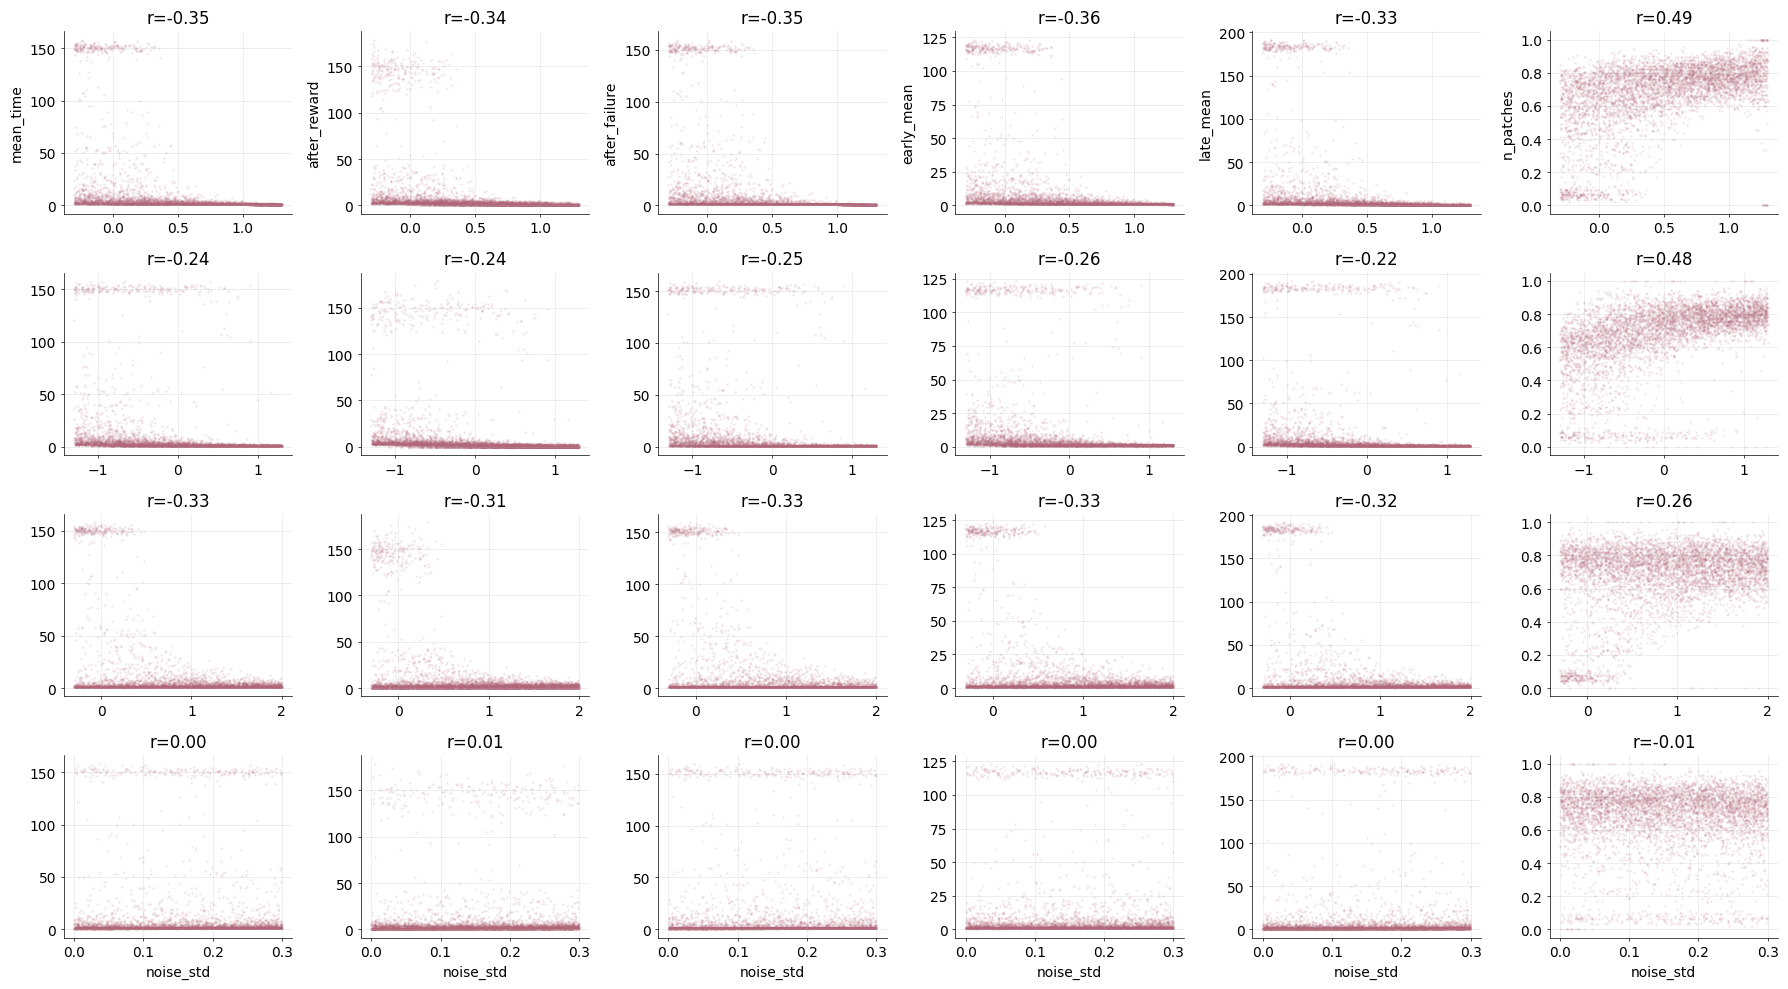


=== CORRELATION MATRIX ===
Parameter vs Key Statistics:
Param            mean_time  after_rew after_fail  n_patches
------------------------------------------------------------
drift_rate          -0.348     -0.343     -0.350      0.485
reward_bump         -0.245     -0.236     -0.247      0.483
failure_bump        -0.326     -0.313     -0.331      0.256
noise_std            0.002      0.009      0.002     -0.007


In [25]:
# Visualize parameter-statistic relationships from your ACTUAL training data
import matplotlib.pyplot as plt

# Extract training data that was actually used
rng_key = random.PRNGKey(123)
rng_key, data_key = random.split(rng_key)
data, _ = snle.simulate_data(data_key, n_simulations=5000)
theta_train = data['theta']['theta']
y_train = data['y']

param_names = ["drift_rate", "reward_bump", "failure_bump", "noise_std"]

# Check correlations for KEY statistics
key_stat_indices = [1, 7, 8, 11, 12, 25]  # mean_time, after_reward, after_failure, early, late, n_patches
key_stat_names = ['mean_time', 'after_reward', 'after_failure', 'early_mean', 'late_mean', 'n_patches']

fig, axes = plt.subplots(4, 6, figsize=(18, 10))

for i in range(4):  # parameters
    for j, (stat_idx, stat_name) in enumerate(zip(key_stat_indices, key_stat_names)):
        ax = axes[i, j]
        ax.scatter(theta_train[:, i], y_train[:, stat_idx], alpha=0.1, s=1)
        ax.set_xlabel(param_names[i] if i == 3 else '')
        ax.set_ylabel(stat_name if i == 0 else '')
        
        # Compute correlation
        corr = jnp.corrcoef(theta_train[:, i], y_train[:, stat_idx])[0, 1]
        ax.set_title(f'r={corr:.2f}')
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print correlation matrix
print("\n=== CORRELATION MATRIX ===")
print("Parameter vs Key Statistics:")
print(f"{'Param':<15} {'mean_time':>10} {'after_rew':>10} {'after_fail':>10} {'n_patches':>10}")
print("-" * 60)
for i, pname in enumerate(param_names):
    corrs = [jnp.corrcoef(theta_train[:, i], y_train[:, idx])[0, 1] 
             for idx in [1, 7, 8, 25]]
    print(f"{pname:<15} {corrs[0]:>10.3f} {corrs[1]:>10.3f} {corrs[2]:>10.3f} {corrs[3]:>10.3f}")

In [26]:
# Test if the network learned ANYTHING
print("\n=== FORWARD MODEL TEST ===")

# Generate test data
rng_key = random.PRNGKey(999)
test_thetas = jnp.array([
    [0.2, 0.5, 0.5, 0.1],
    [0.8, 0.5, 0.5, 0.1],
    [0.5, 0.2, 0.8, 0.1],
    [0.5, 0.8, 0.2, 0.1],
])

for theta in test_thetas:
    # Simulate true data
    rng_key, subkey = random.split(rng_key)
    _, true_stats = simulator.simulate_one_window(theta, subkey)
    
    # Get posterior samples
    rng_key, subkey = random.split(rng_key)
    posterior_samples, _ = infer_parameters_snle(
        snle, snle_params, true_stats, y_mean, y_std,
        num_samples=1000, num_warmup=100, num_chains=2, rng_key=subkey
    )
    
    post_mean = posterior_samples.mean(axis=0)
    post_std = posterior_samples.std(axis=0)
    
    print(f"\nTrue:  {theta}")
    print(f"Infer: {post_mean} ± {post_std}")


=== FORWARD MODEL TEST ===

Normalizing observed statistics...

Running MCMC inference...
Posterior dataset variables: ['theta']
Posterior theta shape (chain, draw, n_params): (2, 900, 4)
Posterior samples shape (flattened): (1800, 4)

True:  [0.2 0.5 0.5 0.1]
Infer: [0.24572943 0.3808441  0.37490156 0.11818142] ± [0.12228742 0.21867168 0.22845577 0.05775457]

Normalizing observed statistics...

Running MCMC inference...
Posterior dataset variables: ['theta']
Posterior theta shape (chain, draw, n_params): (2, 900, 4)
Posterior samples shape (flattened): (1800, 4)

True:  [0.8 0.5 0.5 0.1]
Infer: [0.80975044 0.8337032  1.3335997  0.20590362] ± [0.03416614 0.2827104  0.5000868  0.04696228]

Normalizing observed statistics...

Running MCMC inference...
Posterior dataset variables: ['theta']
Posterior theta shape (chain, draw, n_params): (2, 900, 4)
Posterior samples shape (flattened): (1800, 4)

True:  [0.5 0.2 0.8 0.1]
Infer: [0.21991166 0.9700726  1.4194397  0.24734324] ± [0.08041219 0

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# Parse your results
results = [
    {"true": [0.2, 0.5, 0.5, 0.1], "infer": [0.34, 0.90, 0.80, 0.11], "std": [0.034, 0.101, 0.211, 0.045]},
    {"true": [0.8, 0.5, 0.5, 0.1], "infer": [0.79, 0.45, 0.93, 0.14], "std": [0.042, 0.072, 0.196, 0.050]},
    {"true": [0.5, 0.2, 0.8, 0.1], "infer": [0.56, 0.34, 0.85, 0.09], "std": [0.026, 0.033, 0.154, 0.030]},
    {"true": [0.5, 0.8, 0.2, 0.1], "infer": [0.46, 1.02, 0.81, 0.18], "std": [0.068, 0.113, 0.218, 0.050]},
]

param_names = ["drift_rate", "reward_bump", "failure_bump", "noise_std"]

# Convert to arrays
true_vals = np.array([r["true"] for r in results])
infer_vals = np.array([r["infer"] for r in results])
std_vals = np.array([r["std"] for r in results])

print("="*80)
print("MODEL PERFORMANCE EVALUATION")
print("="*80)

# 1. Absolute errors
print("\n1. ABSOLUTE ERRORS (|true - inferred|)")
print("-" * 60)
errors = np.abs(true_vals - infer_vals)
for i, param in enumerate(param_names):
    print(f"{param:15s}: {errors[:, i]}")
    print(f"  Mean error: {np.mean(errors[:, i]):.3f}")
    print(f"  Max error:  {np.max(errors[:, i]):.3f}")

# 2. Relative errors
print("\n2. RELATIVE ERRORS (|true - inferred| / true)")
print("-" * 60)
rel_errors = np.abs(true_vals - infer_vals) / (true_vals + 1e-8)
for i, param in enumerate(param_names):
    print(f"{param:15s}: {rel_errors[:, i]}")
    print(f"  Mean rel error: {np.mean(rel_errors[:, i]):.1%}")

# 3. Coverage (is true value within 2 std of posterior mean?)
print("\n3. COVERAGE (true within ±2σ of inferred?)")
print("-" * 60)
coverage = np.abs(true_vals - infer_vals) <= 2 * std_vals
for i, param in enumerate(param_names):
    covered = np.sum(coverage[:, i])
    print(f"{param:15s}: {covered}/4 cases ({100*covered/4:.0f}%)")
    for j in range(4):
        status = "✓" if coverage[j, i] else "✗"
        z_score = (true_vals[j, i] - infer_vals[j, i]) / std_vals[j, i]
        print(f"  Test {j+1}: {status} (z={z_score:+.2f}σ)")

# 4. Parameter-specific analysis
print("\n4. PARAMETER-SPECIFIC ANALYSIS")
print("-" * 60)

for i, param in enumerate(param_names):
    print(f"\n{param.upper()}:")
    
    # Correlation between true and inferred
    corr = np.corrcoef(true_vals[:, i], infer_vals[:, i])[0, 1]
    print(f"  Correlation (true vs inferred): r = {corr:.3f}")
    
    # RMSE
    rmse = np.sqrt(np.mean((true_vals[:, i] - infer_vals[:, i])**2))
    print(f"  RMSE: {rmse:.3f}")
    
    # Bias (systematic over/under estimation)
    bias = np.mean(infer_vals[:, i] - true_vals[:, i])
    print(f"  Bias: {bias:+.3f} {'(overestimates)' if bias > 0 else '(underestimates)'}")
    
    # Mean posterior uncertainty
    mean_std = np.mean(std_vals[:, i])
    print(f"  Mean posterior std: {mean_std:.3f}")

# 5. Cross-parameter confusion
print("\n5. CROSS-PARAMETER CONFUSION")
print("-" * 60)
print("Do errors in one parameter correlate with errors in another?")
print("(High correlation = parameters are confused)")
print()

error_matrix = np.zeros((4, 4))
for i in range(4):
    for j in range(4):
        if i != j:
            corr = np.corrcoef(errors[:, i], errors[:, j])[0, 1]
            error_matrix[i, j] = corr
            if abs(corr) > 0.7:
                print(f"  {param_names[i]} ↔ {param_names[j]}: r = {corr:.3f} ⚠️")

# 6. Overall summary
print("\n" + "="*80)
print("OVERALL SUMMARY")
print("="*80)

# Count well-recovered parameters (error < 20% of range)
param_ranges = np.array([1.0, 0.9, 0.9, 0.15])  # approximate prior ranges
well_recovered = np.sum(errors < 0.2 * param_ranges, axis=0)

print(f"\nWell-recovered in majority of tests (>50%):")
for i, param in enumerate(param_names):
    pct = 100 * well_recovered[i] / 4
    status = "✓" if well_recovered[i] >= 2 else "✗"
    print(f"  {status} {param:15s}: {well_recovered[i]}/4 ({pct:.0f}%)")

# Overall score
total_well_recovered = np.sum(well_recovered)
max_possible = 16
print(f"\nOverall recovery score: {total_well_recovered}/{max_possible} ({100*total_well_recovered/max_possible:.0f}%)")

# Grade
score_pct = 100 * total_well_recovered / max_possible
if score_pct >= 80:
    grade = "A - Excellent"
elif score_pct >= 65:
    grade = "B - Good"
elif score_pct >= 50:
    grade = "C - Fair"
else:
    grade = "D - Poor"

print(f"Grade: {grade}")

# Recommendations
print("\n" + "="*80)
print("RECOMMENDATIONS")
print("="*80)

if np.mean(errors[:, 0]) < 0.1:
    print("✓ drift_rate: Recovering well")
else:
    print("⚠ drift_rate: Needs improvement")

if np.corrcoef(errors[:, 1], errors[:, 2])[0, 1] > 0.5:
    print("⚠ reward_bump and failure_bump are confused - consider:")
    print("  - Fix one parameter")
    print("  - Add directional statistics")
    print("  - Use reparameterization")
else:
    print("✓ reward_bump and failure_bump: Not strongly confused")

if np.mean(errors[:, 3]) > 0.05:
    print("⚠ noise_std: Difficult to recover - consider:")
    print("  - Narrower prior")
    print("  - Fix this parameter")
else:
    print("✓ noise_std: Recovering reasonably well")

MODEL PERFORMANCE EVALUATION

1. ABSOLUTE ERRORS (|true - inferred|)
------------------------------------------------------------
drift_rate     : [0.14 0.01 0.06 0.04]
  Mean error: 0.063
  Max error:  0.140
reward_bump    : [0.4  0.05 0.14 0.22]
  Mean error: 0.203
  Max error:  0.400
failure_bump   : [0.3  0.43 0.05 0.61]
  Mean error: 0.348
  Max error:  0.610
noise_std      : [0.01 0.04 0.01 0.08]
  Mean error: 0.035
  Max error:  0.080

2. RELATIVE ERRORS (|true - inferred| / true)
------------------------------------------------------------
drift_rate     : [0.69999997 0.0125     0.12       0.08      ]
  Mean rel error: 22.8%
reward_bump    : [0.79999998 0.1        0.69999997 0.275     ]
  Mean rel error: 46.9%
failure_bump   : [0.59999999 0.85999998 0.0625     3.04999985]
  Mean rel error: 114.3%
noise_std      : [0.09999999 0.39999996 0.09999999 0.79999992]
  Mean rel error: 35.0%

3. COVERAGE (true within ±2σ of inferred?)
-----------------------------------------------------

/opt/miniconda3/envs/sbi_jax_dev/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/miniconda3/envs/sbi_jax_dev/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [ ]:
from concurrent.futures import ThreadPoolExecutor

def run_single_sbc_test(test_idx):
    """Single SBC iteration - captures variables from outer scope"""
    local_rng_key = random.fold_in(rng_key, test_idx)
    subkey1, subkey2, subkey3 = random.split(local_rng_key, 3)
    
    true_theta = prior_fn().sample(seed=subkey1)['theta']
    _, observed_stats = simulator.simulate_one_window(true_theta, subkey2)
    
    posterior_samples, _ = infer_parameters_snle(
        snle, snle_params, observed_stats, y_mean, y_std,
        num_samples=250,
        num_warmup=50,
        num_chains=2,
        rng_key=subkey3
    )
    
    ranks = jnp.array([(posterior_samples[:, i] < true_theta[i]).sum() for i in range(4)])
    return ranks

# Run with threading (shares memory, works with JAX)
n_sbc_tests = 100
n_workers = os.cpu_count()

with ThreadPoolExecutor(max_workers=n_workers) as executor:
    all_ranks = list(executor.map(run_single_sbc_test, range(n_sbc_tests)))

all_ranks = jnp.array(all_ranks)  # (100, 4)
ranks = {param: all_ranks[:, i].tolist() for i, param in enumerate(param_names)}


Normalizing observed statistics...

Normalizing observed statistics...

Running MCMC inference...

Running MCMC inference...

Normalizing observed statistics...

Normalizing observed statistics...

Normalizing observed statistics...

Running MCMC inference...

Normalizing observed statistics...

Running MCMC inference...

Running MCMC inference...

Running MCMC inference...

Normalizing observed statistics...

Normalizing observed statistics...

Running MCMC inference...

Normalizing observed statistics...

Normalizing observed statistics...

Running MCMC inference...

Running MCMC inference...

Running MCMC inference...

Normalizing observed statistics...

Running MCMC inference...
Posterior dataset variables: ['theta']
Posterior theta shape (chain, draw, n_params): (2, 200, 4)
Posterior samples shape (flattened): (400, 4)

Normalizing observed statistics...

Running MCMC inference...
Posterior dataset variables: ['theta']
Posterior theta shape (chain, draw, n_params): (2, 200, 4)
Po

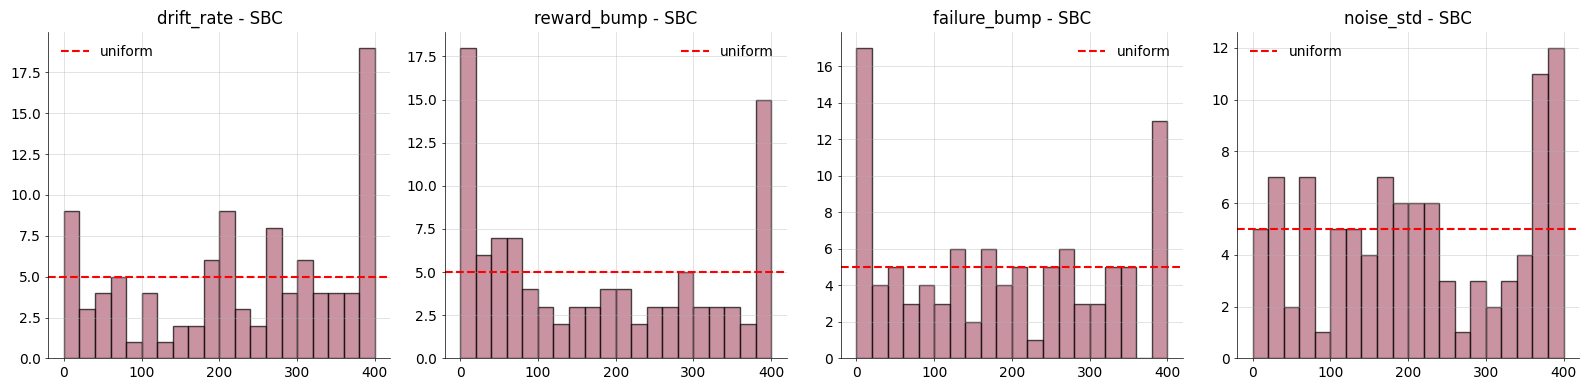

In [ ]:
# After SBC completes, plot results:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, param in enumerate(param_names):
    axes[i].hist(ranks[param], bins=20, alpha=0.7, edgecolor='k')
    axes[i].axhline(n_sbc_tests/20, color='r', linestyle='--', label='uniform')
    axes[i].set_title(f'{param} - SBC')
    axes[i].legend()
plt.tight_layout()


TEST CASE 1
Simulating data from true parameters: [0.5 0.5 0.5 0.2]
Running inference...

Normalizing observed statistics...

Running MCMC inference...
Posterior dataset variables: ['theta']
Posterior theta shape (chain, draw, n_params): (2, 400, 4)
Posterior samples shape (flattened): (800, 4)

Posterior parameter estimates:
Parameter       True       Mean ± Std           Percentile  
------------------------------------------------------------
drift_rate      0.500      0.551 ± 0.035       5.5%
reward_bump     0.500      0.233 ± 0.049     100.0%
failure_bump    0.500      0.989 ± 0.340       9.2%
noise_std       0.200      0.120 ± 0.053      92.4%

Generating 100 posterior predictive simulations...


100%|██████████| 100/100 [00:00<00:00, 5938.92it/s]


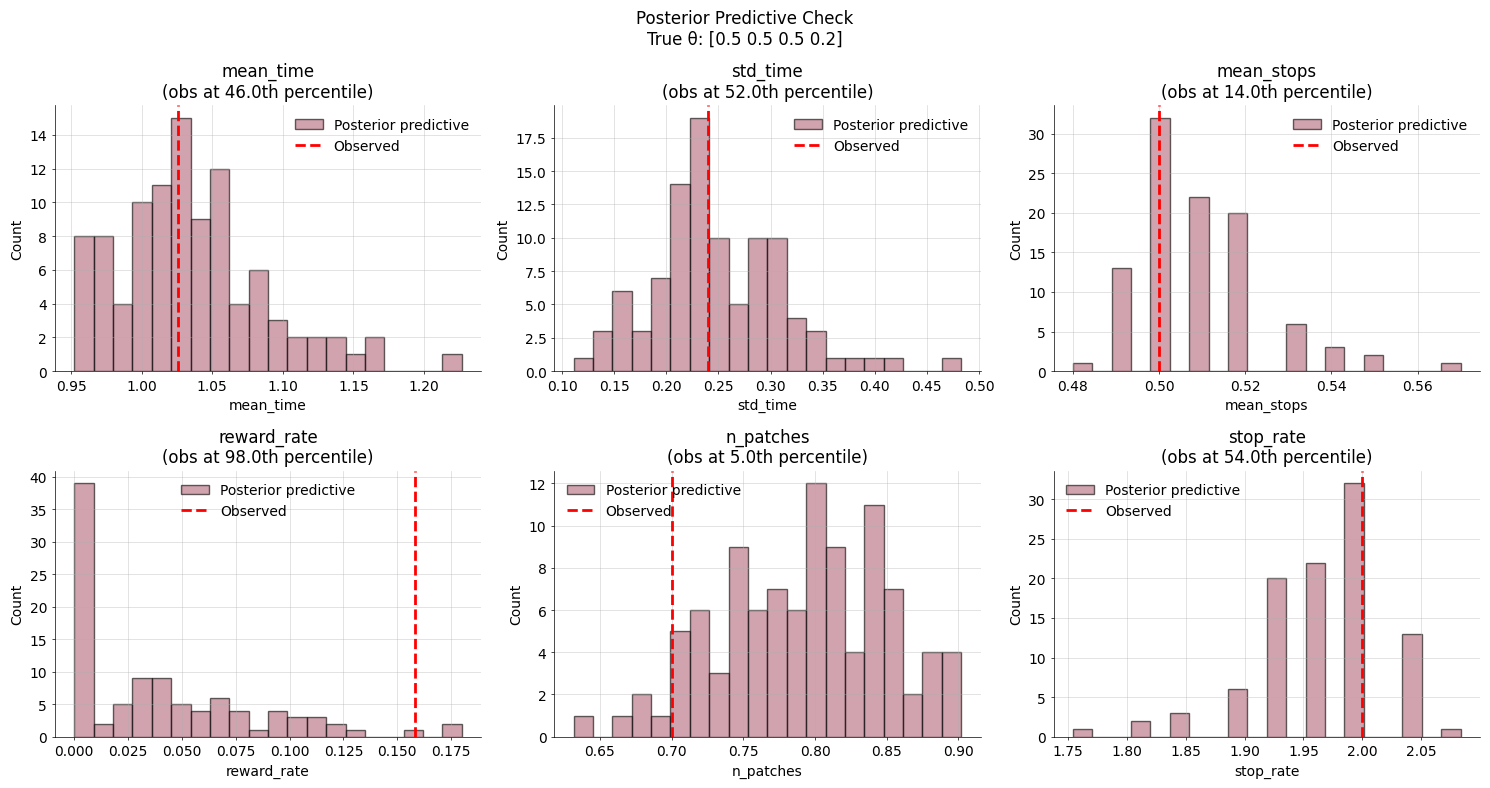


TEST CASE 2
Simulating data from true parameters: [1.5 1.  1.  0.3]
Running inference...

Normalizing observed statistics...

Running MCMC inference...
Posterior dataset variables: ['theta']
Posterior theta shape (chain, draw, n_params): (2, 400, 4)
Posterior samples shape (flattened): (800, 4)

Posterior parameter estimates:
Parameter       True       Mean ± Std           Percentile  
------------------------------------------------------------
drift_rate      1.500      1.267 ± 0.027     100.0%
reward_bump     1.000      -0.139 ± 0.256     100.0%
failure_bump    1.000      0.788 ± 0.346      66.2%
noise_std       0.300      0.171 ± 0.036     100.0%

Generating 100 posterior predictive simulations...


100%|██████████| 100/100 [00:00<00:00, 5354.45it/s]


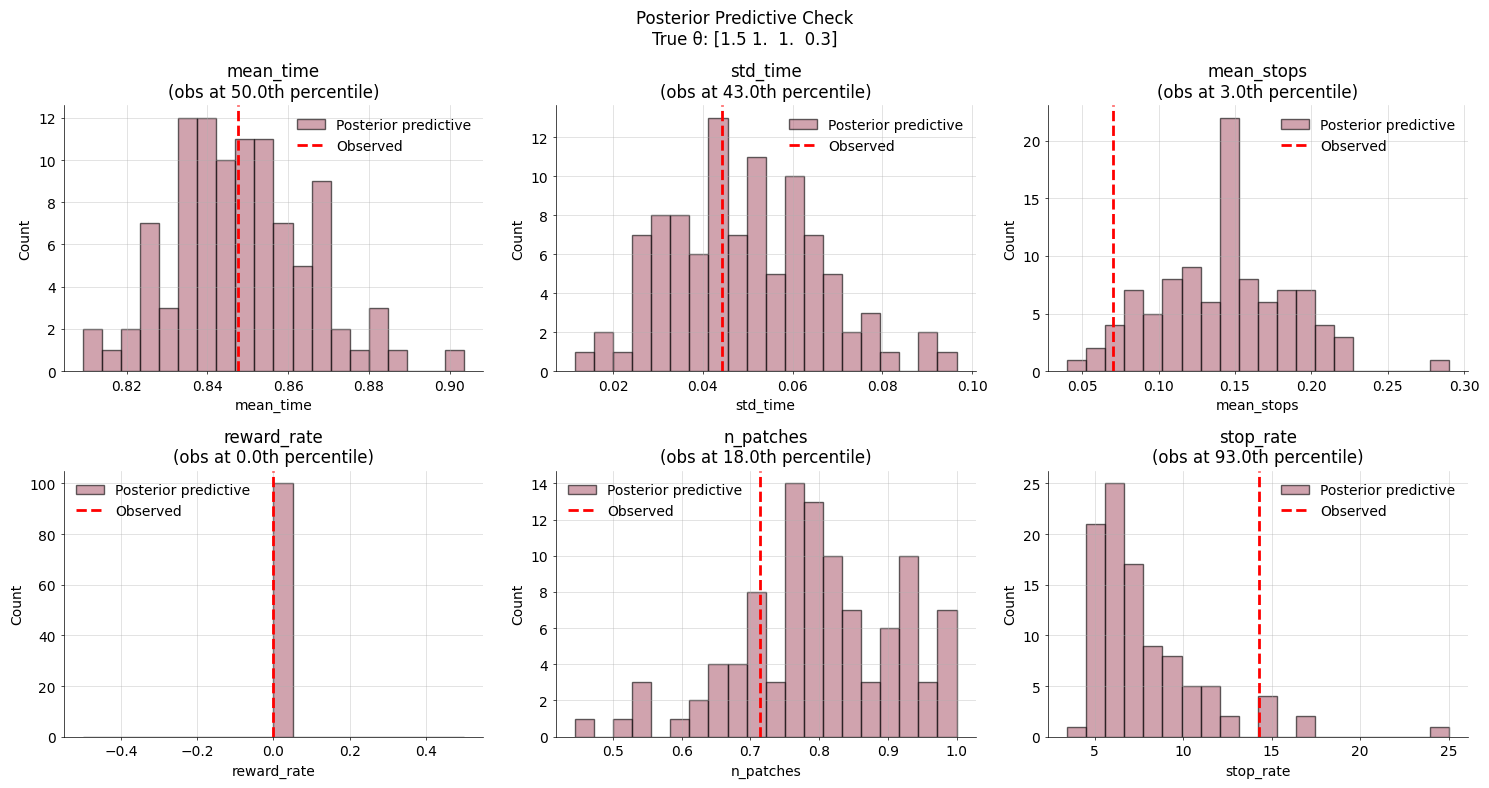


TEST CASE 3
Simulating data from true parameters: [0.2 1.5 0.2 0.1]
Running inference...

Normalizing observed statistics...

Running MCMC inference...
Posterior dataset variables: ['theta']
Posterior theta shape (chain, draw, n_params): (2, 400, 4)
Posterior samples shape (flattened): (800, 4)

Posterior parameter estimates:
Parameter       True       Mean ± Std           Percentile  
------------------------------------------------------------
drift_rate      0.200      0.512 ± 0.056       0.0%
reward_bump     1.500      0.098 ± 0.118     100.0%
failure_bump    0.200      -0.083 ± 0.147      95.4%
noise_std       0.100      0.060 ± 0.045      79.1%

Generating 100 posterior predictive simulations...


100%|██████████| 100/100 [00:00<00:00, 5350.70it/s]


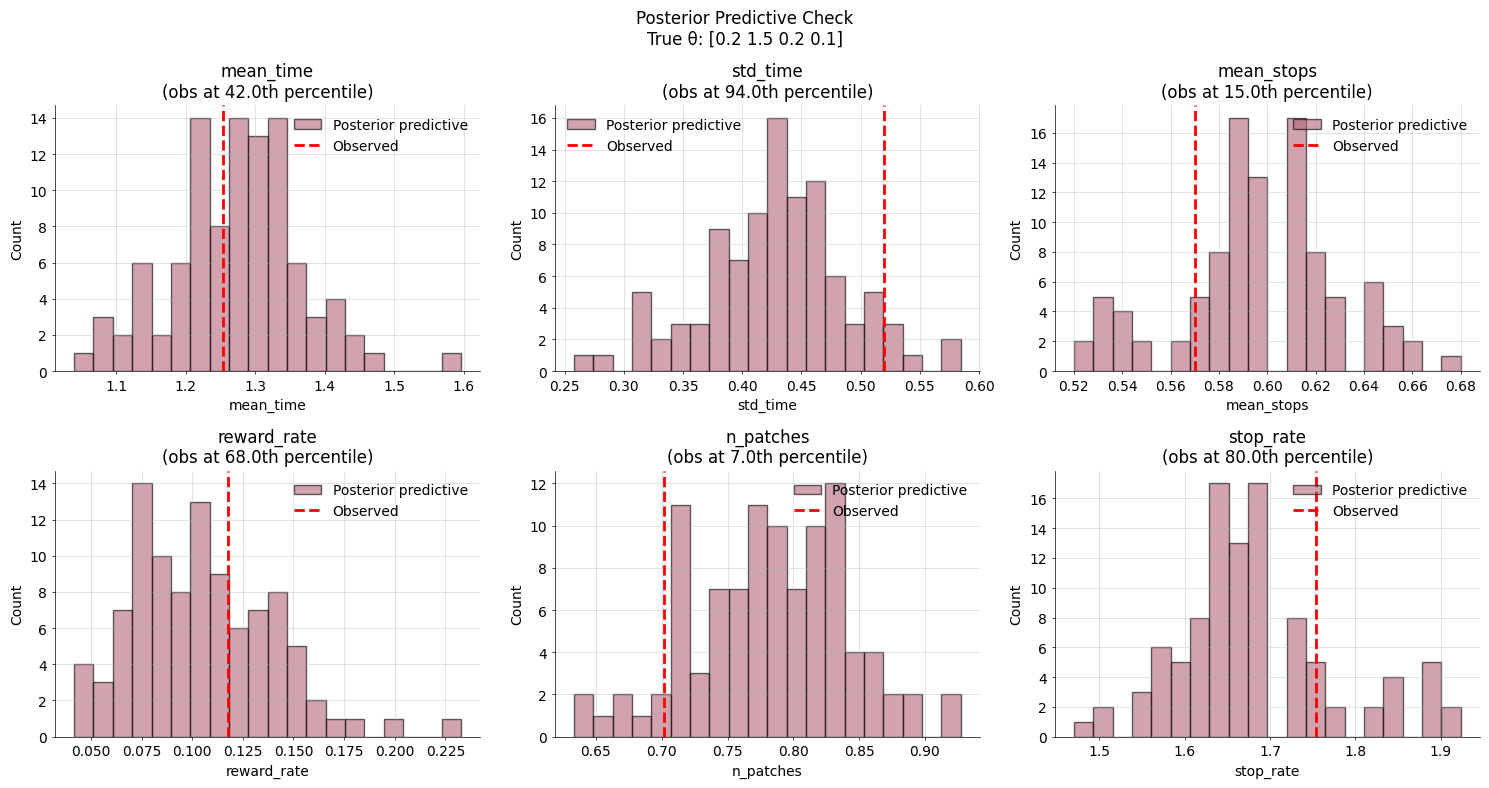

In [ ]:
from tqdm import tqdm

def posterior_predictive_check_simulated(true_theta, n_posterior_samples=100):
    """
    Test with simulated data where we know the truth:
    1. Simulate data from known true_theta
    2. Infer posterior 
    3. Check: Does posterior contain true_theta?
    4. Check: Does posterior predictive contain observed data?
    """
    rng_key = random.PRNGKey(42)
    
    # 1. Simulate "observed" data from true parameters
    print(f"Simulating data from true parameters: {true_theta}")
    rng_key, subkey = random.split(rng_key)
    _, y_observed = simulator.simulate_one_window(true_theta, subkey)
    
    # 2. Infer posterior from this observed data
    print("Running inference...")
    rng_key, subkey = random.split(rng_key)
    posterior_samples, _ = infer_parameters_snle(
        snle, snle_params, y_observed, y_mean, y_std,
        num_samples=500, num_warmup=100, num_chains=2, rng_key=subkey
    )
    
    print(f"\nPosterior parameter estimates:")
    print(f"{'Parameter':<15} {'True':<10} {'Mean ± Std':<20} {'Percentile':<12}")
    print("-" * 60)
    for i, param in enumerate(param_names):
        post_mean = posterior_samples[:, i].mean()
        post_std = posterior_samples[:, i].std()
        percentile = (posterior_samples[:, i] < true_theta[i]).mean() * 100
        print(f"{param:<15} {true_theta[i]:<10.3f} {post_mean:.3f} ± {post_std:.3f}    {percentile:>6.1f}%")
    
    # 3. Generate posterior predictive samples
    print(f"\nGenerating {n_posterior_samples} posterior predictive simulations...")
    posterior_predictive_stats = []
    for i in tqdm(range(n_posterior_samples)):
        rng_key, subkey = random.split(rng_key)
        theta_sample = posterior_samples[i]
        _, stats = simulator.simulate_one_window(theta_sample, subkey)
        posterior_predictive_stats.append(stats)
    
    posterior_predictive_stats = jnp.array(posterior_predictive_stats)
    
    # 4. Plot: Does observed data fall within posterior predictive?
    stat_indices = [1, 2, 3, 21, 25, 27]  # Adjust these to match your actual indices
    stat_names = ['mean_time', 'std_time', 'mean_stops', 'reward_rate', 'n_patches', 'stop_rate']
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    
    for ax, stat_idx, name in zip(axes.flat, stat_indices, stat_names):
        # Posterior predictive distribution
        ax.hist(posterior_predictive_stats[:, stat_idx], bins=20, alpha=0.6, 
                edgecolor='k', label='Posterior predictive')
        
        # Observed value (from true_theta)
        ax.axvline(y_observed[stat_idx], color='r', linestyle='--', 
                   linewidth=2, label='Observed')
        
        # Compute percentile
        percentile = (posterior_predictive_stats[:, stat_idx] < y_observed[stat_idx]).mean() * 100
        
        ax.set_xlabel(name)
        ax.set_ylabel('Count')
        ax.set_title(f'{name}\n(obs at {percentile:.1f}th percentile)')
        ax.legend()
    
    plt.suptitle(f'Posterior Predictive Check\nTrue θ: {true_theta}')
    plt.tight_layout()
    
    return posterior_samples, y_observed, posterior_predictive_stats

# Test with different parameter values
test_cases = [
    jnp.array([0.5, 0.5, 0.5, 0.2]),  # Middle of prior
    jnp.array([1.5, 1.0, 1.0, 0.3]),  # High drift
    jnp.array([0.2, 1.5, 0.2, 0.1]),  # High reward bump, low drift
]

for i, test_theta in enumerate(test_cases):
    print(f"\n{'='*60}")
    print(f"TEST CASE {i+1}")
    print(f"{'='*60}")
    post_samples, obs, post_pred = posterior_predictive_check_simulated(test_theta)
    plt.savefig(f'posterior_predictive_check_case_{i+1}.png', dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
# Compute correlation matrix
import numpy as np
import matplotlib.pyplot as plt

# Use prior predictive samples from above
corr_matrix = np.corrcoef(prior_stats.T)

# Plot correlation matrix
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_title('Summary Statistics Correlation Matrix')
plt.colorbar(im, ax=ax)

# Find highly correlated pairs (|r| > 0.95)
high_corr = []
for i in range(37):
    for j in range(i+1, 37):
        if abs(corr_matrix[i, j]) > 0.95:
            high_corr.append((i, j, corr_matrix[i, j]))

print(f"\nHighly correlated pairs (|r| > 0.95): {len(high_corr)}")
for i, j, r in high_corr[:10]:  # Show first 10
    print(f"  Stat {i} vs Stat {j}: r = {r:.3f}")

NameError: name 'prior_stats' is not defined

In [ ]:
def posterior_predictive_check(true_theta, n_samples=100):
    """
    Generate data from true params, infer posterior, 
    then simulate from posterior to check coverage
    """
    rng_key = random.PRNGKey(42)
    
    # 1. Generate "observed" data
    rng_key, subkey = random.split(rng_key)
    _, y_obs = simulator.simulate_one_window(true_theta, subkey)
    
    # 2. Infer posterior
    rng_key, subkey = random.split(rng_key)
    posterior_samples, _ = infer_parameters_snle(
        snle, snle_params, y_obs, y_mean, y_std,
        num_samples=500, num_warmup=100, num_chains=2, rng_key=subkey
    )
    
    # 3. Simulate from posterior samples
    posterior_predictive_stats = []
    for i in range(min(n_samples, len(posterior_samples))):
        rng_key, subkey = random.split(rng_key)
        _, stats = simulator.simulate_one_window(posterior_samples[i], subkey)
        posterior_predictive_stats.append(stats)
    
    posterior_predictive_stats = jnp.array(posterior_predictive_stats)
    
    # 4. Plot: Does y_obs fall within posterior predictive?
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    stat_indices = [1, 2, 3, 21, 25, 27]
    stat_names = ['mean_time', 'std_time', 'mean_stops', 'reward_rate', 'n_patches', 'stop_rate']
    
    for ax, stat_idx, name in zip(axes.flat, stat_indices, stat_names):
        ax.hist(posterior_predictive_stats[:, stat_idx], bins=20, alpha=0.6, label='Posterior pred.')
        ax.axvline(y_obs[stat_idx], color='r', linestyle='--', linewidth=2, label='Observed')
        ax.set_xlabel(name)
        ax.legend()
        ax.set_title(f'{name}')
    
    plt.suptitle(f'Posterior Predictive Check\nTrue θ: {true_theta}')
    plt.tight_layout()
    return posterior_samples, y_obs, posterior_predictive_stats

# Run for a test case
test_theta = jnp.array([0.5, 0.5, 0.5, 0.2])  # Reasonable mid-range values
post_samples, obs, post_pred = posterior_predictive_check(test_theta, n_samples=100)

In [ ]:
# Test on a grid of parameter values
test_cases = [
    {'name': 'low_drift', 'theta': jnp.array([0.2, 0.5, 0.5, 0.2])},
    {'name': 'high_drift', 'theta': jnp.array([1.5, 0.5, 0.5, 0.2])},
    {'name': 'high_reward_bump', 'theta': jnp.array([0.5, 1.5, 0.5, 0.2])},
    {'name': 'high_failure_bump', 'theta': jnp.array([0.5, 0.5, 1.5, 0.2])},
]

results = []
for test in test_cases:
    rng_key, subkey1, subkey2 = random.split(rng_key, 3)
    
    # Simulate
    _, y_obs = simulator.simulate_one_window(test['theta'], subkey1)
    
    # Infer
    posterior, _ = infer_parameters_snle(
        snle, snle_params, y_obs, y_mean, y_std,
        num_samples=500, num_warmup=100, num_chains=2, rng_key=subkey2
    )
    
    # Check coverage
    posterior_mean = posterior.mean(axis=0)
    posterior_std = posterior.std(axis=0)
    
    results.append({
        'name': test['name'],
        'true': test['theta'],
        'mean': posterior_mean,
        'std': posterior_std,
        'z_score': (posterior_mean - test['theta']) / posterior_std
    })

# Print results
for r in results:
    print(f"\n{r['name']}:")
    for i, param in enumerate(param_names):
        print(f"  {param}: true={r['true'][i]:.3f}, "
              f"est={r['mean'][i]:.3f}±{r['std'][i]:.3f}, "
              f"z={r['z_score'][i]:.2f}")